# import and seed 

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.base import clone

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.model_selection import KFold
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score,
    classification_report, mean_squared_error,
    precision_recall_fscore_support
)
from sklearn.compose import ColumnTransformer

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

from imblearn.pipeline import Pipeline 
from imblearn.over_sampling import SMOTE
from collections import OrderedDict
from sklearn.base import clone

%precision 3
pd.set_option('display.precision', 3)
np.set_printoptions(suppress=True, precision=3)

import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
#from catboost import CatBoostClassifier

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score,
    classification_report, mean_squared_error,
    precision_recall_fscore_support
)

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

from collections import OrderedDict

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

%precision 3
pd.set_option('display.precision', 3)
np.set_printoptions(suppress=True, precision=3)

import warnings
warnings.filterwarnings("ignore")
%load_ext autoreload
%autoreload 2


import sys

import os
# Add the project root to the Python path
sys.path.append(os.path.abspath('..'))


import lib.helper_fun 


import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
#from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:

import random
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# Test train split

In [3]:

data = pd.read_csv('data_enriched.csv')
data = data.drop(columns=["Unnamed: 0"], errors="ignore")

X_train, X_valid, y_train, y_valid = lib.helper_fun.random_split(data, label_col= "is_relevant")



In [4]:
print(f'train: {y_train.shape}')
print(y_train.value_counts(normalize=True))
print(f'test: {y_valid.shape}')
print(y_valid.value_counts(normalize=True))


train: (5042,)
is_relevant
0.0    0.804
1.0    0.196
Name: proportion, dtype: float64
test: (1261,)
is_relevant
0.0    0.804
1.0    0.196
Name: proportion, dtype: float64


# feature definitions 

In [5]:
drop_columns = [
    "datetime",   
    "date",                 # converted to time deltas
    "description",          # redundant fallback for text
    "article_text",         # too large for tabular use
    "url_slug_title",       # raw text (used already to create other features)
    "article_type", 
    "extracted_entities",
    "entity_relationships", 
    "text_input"
]

# Drop the columns from data
data = data.drop(columns=drop_columns, errors="ignore")

# Set the URL as the index
data = data.set_index("url")

In [6]:
target_column = "is_relevant"  

baseline_features = [
    "election_keyword_count",
    "days_until_us_election",
    "days_until_french_election",
    "days_until_german_election"
]

all_features = [col for col in data.columns if col != target_column]

llm_features = [
    col for col in data.columns if col.startswith("L_")
] + ['has_entities', 'has_relationships', 'has_people', 'has_organizations']

publisher_features = [col for col in data.columns if col.startswith("P_")]

non_llm_features = [
    col for col in data.columns
    if col not in llm_features and col not in publisher_features and col != target_column
]

non_llm_features_with_publisher = non_llm_features + publisher_features
features_with_llm = non_llm_features + llm_features
all_features_full = non_llm_features + llm_features + publisher_features

categorical_features = [
    "language",              
    "source",                
    "day_of_week",  
    "month",         
    "triggered_keyword",     
    "news_org", 
    'P_country', 
    'P_freedom_rank', 
    'P_media_type',             
]

binary_flags = [
    "is_weekend", "contains_question", "contains_number",
    "mentions_social_media", "mentions_election_keywords",
    "no_title", "used_description_as_text", "P_bias_missing", 
    "P_factuality_missing"
]

In [7]:
collector_non_llm = lib.helper_fun.ResultCollector()
collector_non_llm_pub = lib.helper_fun.ResultCollector()
collector_llm = lib.helper_fun.ResultCollector()
results = []
best_models = {} 

# Pipeline defintions

In [71]:
# ✅ Logit pipelines
pipe_logit = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(
        penalty='l1',
        solver='liblinear',
        max_iter=1000, 
        random_state=SEED
    ))
])

pipe_logit1 = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(
        penalty='l1',
        solver='liblinear',
        max_iter=1000, 
        random_state=SEED
    ))
])

pipe_logit2 = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(
        penalty='l1',
        solver='liblinear',
        max_iter=1000, 
        random_state=SEED
    ))
])

pipe_logit3 = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(
        penalty='l1',
        solver='liblinear',
        max_iter=1000, 
        random_state=SEED
    ))
])

# ✅ Random Forest pipelines
pipe_rf = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(verbose=0, random_state=SEED))
])

pipe_rf2 = clone(pipe_rf)

# ✅ XGBoost pipelines
pipe_xgb_smote = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(verbosity=0, random_state=SEED))
])

pipe_xgb_smote_pca = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('model', XGBClassifier(verbosity=0, random_state=SEED))
])

pipe_xgb_select_features = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('select_features', SelectKBest(score_func=f_classif, k=30)),
    ('model', XGBClassifier(verbosity=0, random_state=SEED))
])

pipe_xgb_new_smote = Pipeline([
    ('smote', SMOTE(
        random_state=42,
        sampling_strategy=0.40,
        k_neighbors=3
    )),
    ('model', XGBClassifier(verbosity=0, random_state=SEED))
])

# ✅ Copies for more experiments

pipe_xgb_smote2 = clone(pipe_xgb_smote)
pipe_xgb_smote_pca2 = clone(pipe_xgb_smote_pca)
pipe_xgb_select_features2 = clone(pipe_xgb_select_features)
pipe_xgb_new_smote2 = clone(pipe_xgb_new_smote)

pipe_xgb_smote3 = clone(pipe_xgb_smote)
pipe_xgb_smote_pca3 = clone(pipe_xgb_smote_pca)
pipe_xgb_select_features3 = clone(pipe_xgb_select_features)
pipe_xgb_new_smote3 = clone(pipe_xgb_new_smote)

# ✅ CatBoost pipelines
pipe_cat = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', CatBoostClassifier(verbose=0, random_state=SEED, cat_features=categorical_features,))
])

pipe_cat2 = clone(pipe_cat)

# ✅ Neural Network pipelines
# Commented because they used isotonic calibration previously
# pipe_mlp = Pipeline([
#     ('smote', SMOTE(random_state=42)),
#     ('model', MLPClassifier(max_iter=1000, early_stopping=True, random_state=42))
# ])
# pipe_mlp2 = pipe_mlp

# param grid setup 

In [12]:
# 📝 Logistic Regression Param Grid (no calibration wrapper)
logit_param_grid = {
    "model__C": [0.1, 1.0],
    "model__penalty": ["l1"]
}

# 📝 Random Forest Param Grid (no calibration wrapper)
rf_param_grid = {
    "model__n_estimators": [100, 200, 500],
    "model__max_depth": [5, 10, 15],
    "model__min_samples_split": [2, 5, 10],
    "model__criterion": ["gini", "entropy"],
    "model__max_features": ["sqrt", "log2"]
}

# 📝 XGBoost Param Grid (no calibration wrapper)
xgb_param_grid = {
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [4, 5],
    "model__n_estimators": [100, 200],
    "model__subsample": [0.5, 0.7, 0.8],
    "model__colsample_bytree": [0.5, 0.7, 0.8]
}

# 📝 CatBoost Param Grid (no calibration wrapper)
catboost_param_grid = {
    "model__learning_rate": [0.05, 0.1],
    "model__depth": [5, 10],
    "model__iterations": [100, 200],
    "model__l2_leaf_reg": [1, 5],
    "model__penalties_coefficient": [0, 1]
}

# cost function

In [13]:
FN_COST = 4   # False Negative: Missed election-relevant article
FP_COST = 1   # False Positive: Article wrongly flagged as relevant

# running the models 

## logit 

🔍 Running model: Logit-Baseline


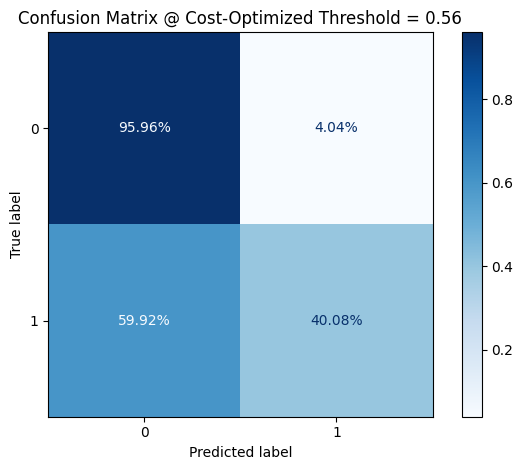


📉 Business Cost Evaluation for Logit-Baseline:
🔹 Best Threshold (Cost-Optimized): 0.564
🔹 Expected Loss: 0.502  [FN cost = 4, FP cost = 1]

📊 Logit-Baseline: Train RMSE = 0.4451, Valid RMSE = 0.4411
✅ Finished: Logit-Baseline



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['election_keyword_count',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  [])])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 LogisticRegression(C=0.1, max_iter=1000, penalty='l1',
                                    random_state=42, solver='liblinear'))])

In [14]:
lib.helper_fun.run_model_with_gridsearch('Logit-Baseline', pipe_logit, logit_param_grid, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector_non_llm,
    baseline_features, categorical_features
)

🔍 Running model: Logit-non_llm


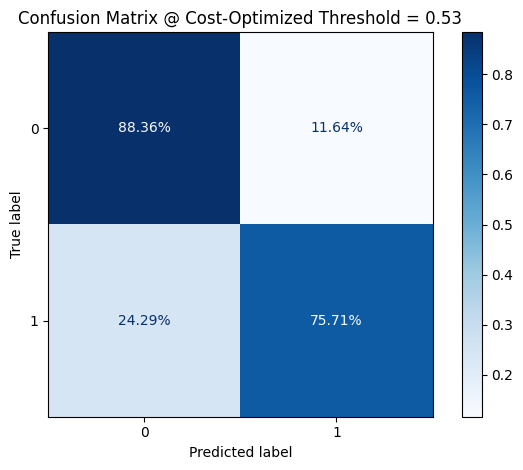


📉 Business Cost Evaluation for Logit-non_llm:
🔹 Best Threshold (Cost-Optimized): 0.535
🔹 Expected Loss: 0.284  [FN cost = 4, FP cost = 1]

📊 Logit-non_llm: Train RMSE = 0.3432, Valid RMSE = 0.3370
✅ Finished: Logit-non_llm



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                                                   'norm_modal_verb_count',
                                                   'norm_future_tense_count',
                                                   'norm_sentence_variance',
                                                   'readability_score']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['language', 'source',
                                                   'news_org', 'day_of_week',
                                                   'month',
                                                   'triggered_keyword'])])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 LogisticRegression(C=0.1, max_iter=1000, penalty='l1',
                                    random_state=42, solver='liblinear'))])

In [15]:
lib.helper_fun.run_model_with_gridsearch('Logit-non_llm', pipe_logit1, logit_param_grid, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector_non_llm,
    non_llm_features, categorical_features
)

🔍 Running model: Logit-non_llm+pub


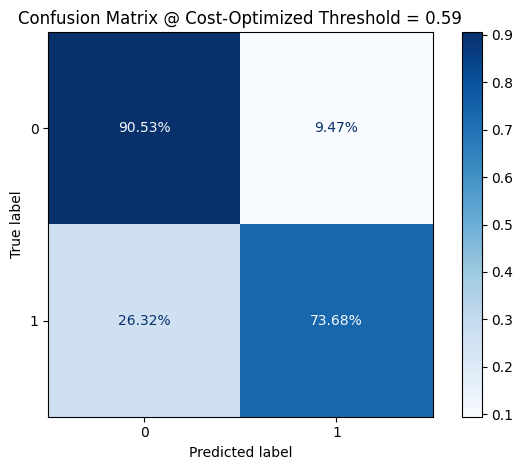


📉 Business Cost Evaluation for Logit-non_llm+pub:
🔹 Best Threshold (Cost-Optimized): 0.594
🔹 Expected Loss: 0.282  [FN cost = 4, FP cost = 1]

📊 Logit-non_llm+pub: Train RMSE = 0.3441, Valid RMSE = 0.3374
✅ Finished: Logit-non_llm+pub



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                                                   'norm_sentence_variance',
                                                   'readability_score',
                                                   'P_bias', ...]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['language', 'source',
                                                   'news_org', 'day_of_week',
                                                   'month', 'triggered_keyword',
                                                   'P_country',
                                                   'P_freedom_rank',
                                                   'P_media_type'])])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 LogisticRegression(C=0.1, max_iter=1000, penalty='l1',
                                    random_state=42, solver='liblinear'))])

In [16]:
lib.helper_fun.run_model_with_gridsearch('Logit-non_llm+pub', pipe_logit2, logit_param_grid, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector_non_llm_pub,
    non_llm_features_with_publisher, categorical_features
)

🔍 Running model: Logit-llm


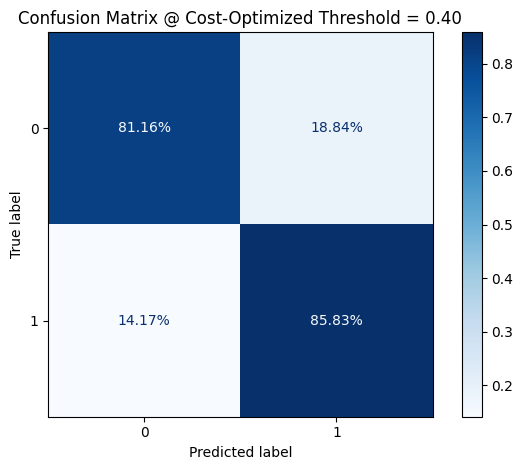


📉 Business Cost Evaluation for Logit-llm:
🔹 Best Threshold (Cost-Optimized): 0.396
🔹 Expected Loss: 0.262  [FN cost = 4, FP cost = 1]

📊 Logit-llm: Train RMSE = 0.3316, Valid RMSE = 0.3286
✅ Finished: Logit-llm



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                                                   'norm_sentence_variance',
                                                   'readability_score',
                                                   'L_n_total_entities', ...]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['language', 'source',
                                                   'news_org', 'day_of_week',
                                                   'month', 'triggered_keyword',
                                                   'P_country',
                                                   'P_freedom_rank',
                                                   'P_media_type'])])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 LogisticRegression(max_iter=1000, penalty='l1',
                                    random_state=42, solver='liblinear'))])

In [17]:
lib.helper_fun.run_model_with_gridsearch('Logit-llm', pipe_logit3, logit_param_grid, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector_llm,
    all_features_full, categorical_features
)

In [18]:
collector_non_llm.get_table()

,Train RMSE,Test RMSE,Expected Loss
Logit-Baseline,0.445,0.441,0.502
Logit-non_llm,0.343,0.337,0.284


## rf

🔍 Running model: rf-non_llm+pub


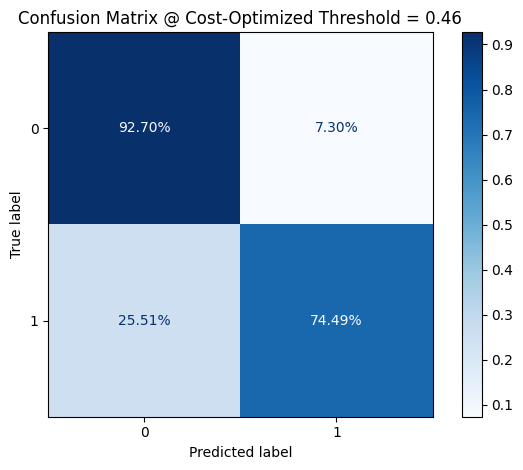


📉 Business Cost Evaluation for rf-non_llm+pub:
🔹 Best Threshold (Cost-Optimized): 0.455
🔹 Expected Loss: 0.259  [FN cost = 4, FP cost = 1]

📊 rf-non_llm+pub: Train RMSE = 0.2104, Valid RMSE = 0.2925
✅ Finished: rf-non_llm+pub



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                                                   'readability_score',
                                                   'P_bias', ...]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['language', 'source',
                                                   'news_org', 'day_of_week',
                                                   'month', 'triggered_keyword',
                                                   'P_country',
                                                   'P_freedom_rank',
                                                   'P_media_type'])])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 RandomForestClassifier(criterion='entropy', max_depth=15,
                                        min_samples_split=10, n_estimators=500,
                                        random_state=42))])

In [78]:
lib.helper_fun.run_model_with_gridsearch('rf-non_llm+pub', pipe_rf, rf_param_grid, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector_non_llm_pub,
    non_llm_features_with_publisher, categorical_features
)

🔍 Running model: rf-llm


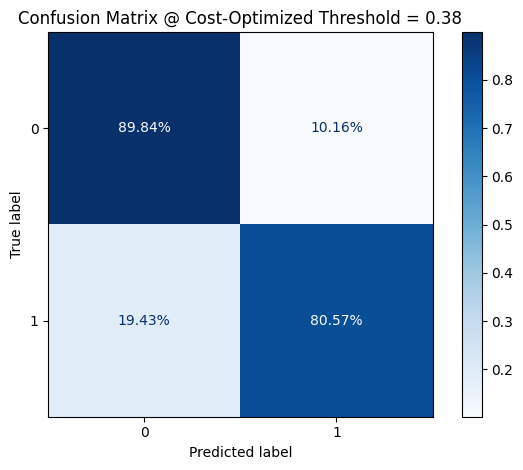


📉 Business Cost Evaluation for rf-llm:
🔹 Best Threshold (Cost-Optimized): 0.376
🔹 Expected Loss: 0.234  [FN cost = 4, FP cost = 1]

📊 rf-llm: Train RMSE = 0.1475, Valid RMSE = 0.2802
✅ Finished: rf-llm



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                                                   'norm_sentence_variance',
                                                   'readability_score',
                                                   'L_n_total_entities', ...]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['language', 'source',
                                                   'news_org', 'day_of_week',
                                                   'month', 'triggered_keyword',
                                                   'P_country',
                                                   'P_freedom_rank',
                                                   'P_media_type'])])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 RandomForestClassifier(criterion='entropy', max_depth=15,
                                        random_state=42))])

In [79]:
lib.helper_fun.run_model_with_gridsearch('rf-llm', pipe_rf2, rf_param_grid, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector_llm,
    all_features_full, categorical_features
)

## xgb

In [19]:
xgb_no_smote_calibrated = Pipeline([
    ('calibrated_model', CalibratedClassifierCV(
        estimator=XGBClassifier(verbosity=0, random_state=SEED),
        cv=KFold(n_splits=5, shuffle=True, random_state=42)
    ))
])

xgb_param_grid0 = {
    "learning_rate": [0.05, 0.1],  # Conservative updates
    "max_depth": [4, 5],            # Shallower trees reduce overfit
    "n_estimators": [100, 200],     # Reasonable training time
    "subsample": [0.5,0.7,0.8],             # Row sampling
    "colsample_bytree": [0.5,0.7,0.8],    # Feature sampling
    # "reg_alpha": [0, 1],            # L1 regularization (sparsity)
    # "reg_lambda": [1, 5],           # L2 regularization (shrinkage)
    # "min_child_weight": [5],        # Avoid splits on tiny nodes
    # "gamma": [0, 0.1]               # Prevent unhelpful splits
}

Fitting 5 folds for each of 72 candidates, totalling 360 fits


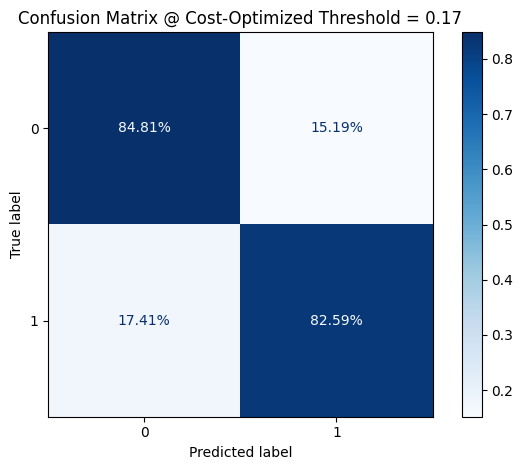

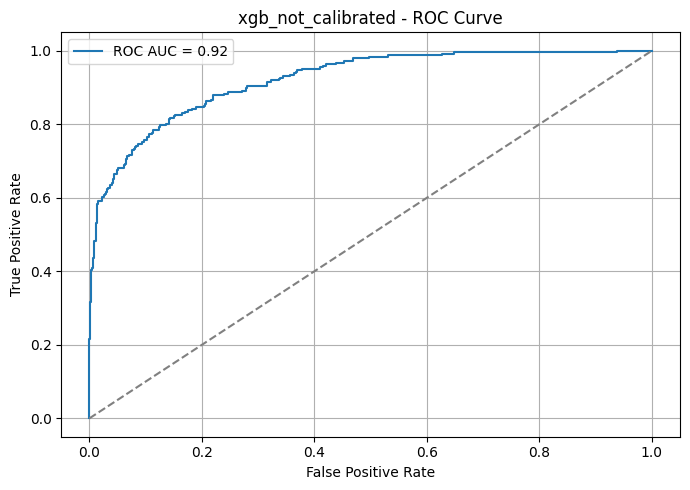

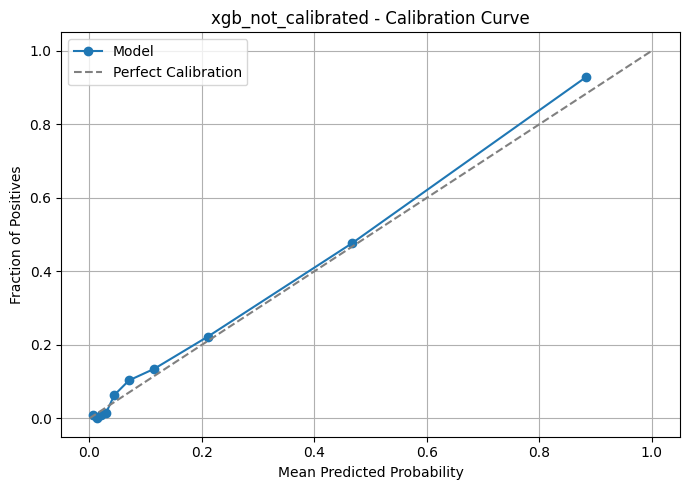

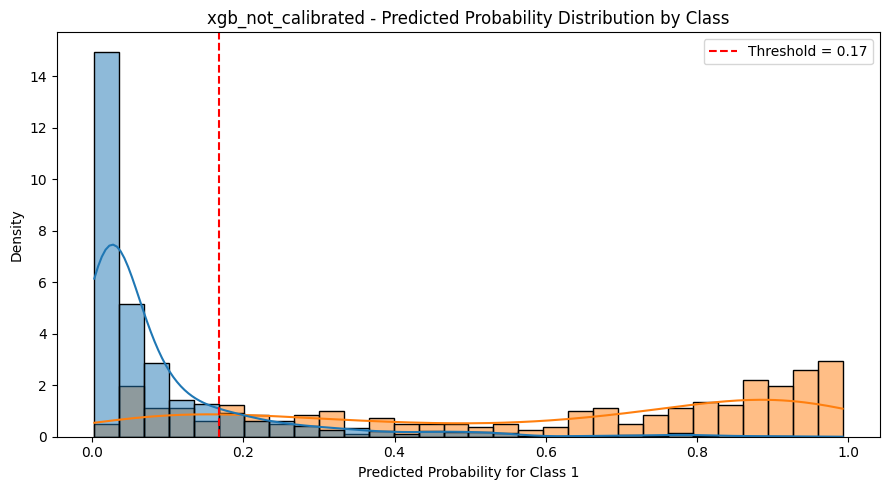


📊 Classification Report (Threshold = 0.17):
              precision    recall  f1-score   support

         0.0      0.952     0.848     0.897      1014
         1.0      0.570     0.826     0.674       247

    accuracy                          0.844      1261
   macro avg      0.761     0.837     0.786      1261
weighted avg      0.877     0.844     0.854      1261


📈 Train RMSE: 0.2749
📈 Test  RMSE: 0.2749


{'Model': 'xgb_not_calibrated',
 'Threshold': 0.168,
 'Train RMSE': 0.275,
 'Test RMSE': 0.275,
 'AUC': 0.921}

In [20]:
# 1. Filter your training and validation sets to only the valid features
X_train_filtered = X_train[non_llm_features]
X_valid_filtered = X_valid[non_llm_features]


# # 2. Define column transformer
# preprocessor = ColumnTransformer(transformers=[
#     ('num', StandardScaler(), [f for f in non_llm_features if f not in categorical_features]),
#     ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
# ])

valid_features = [f for f in non_llm_features if f in X_train_filtered.columns]
valid_categoricals = [f for f in categorical_features if f in X_valid_filtered.columns]

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), [f for f in valid_features if f not in valid_categoricals]),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), valid_categoricals)
])

# 3. Fit-transform on train, transform on valid
X_train_preprocessed = preprocessor.fit_transform(X_train_filtered)
X_valid_preprocessed = preprocessor.transform(X_valid_filtered)


# 2. Run the grid search again with the filtered data
xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42,
    verbosity=0
)

grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_param_grid0,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

# 7. Fit
grid.fit(X_train_preprocessed, y_train)

# 8. Predict and evaluate
best_model = grid.best_estimator_
valid_probs = best_model.predict_proba(X_valid_preprocessed)[:, 1]

lib.helper_fun.diagnostics(
    y_train=y_valid,
    y_train_probs=valid_probs,
    y_valid=y_valid,
    y_valid_probs=valid_probs,
    model_name="xgb_not_calibrated"
)

In [21]:
train_probs = best_model.predict_proba(X_train_preprocessed)[:, 1]
train_rmse = np.sqrt(mean_squared_error(y_train, train_probs))
print(f"📉 Train RMSE: {train_rmse:.4f}")

📉 Train RMSE: 0.2135


In [22]:
train_probs = best_model.predict_proba(X_train_preprocessed)[:, 1]
valid_probs = best_model.predict_proba(X_valid_preprocessed)[:, 1]  # for validation set

threshold, expected_loss = lib.helper_fun.compute_expected_loss(y_valid, valid_probs)

print(f"Best Threshold for Cost Optimization: {threshold:.3f}")
print(f"Expected Loss: {expected_loss:.3f}")

Best Threshold for Cost Optimization: 0.168
Expected Loss: 0.259


run this one 

In [23]:
collector_non_llm.add_model(name = 'xgb_not_calibrated_no_smote', test_rmse = 0.275 , train_rmse = train_rmse , expected_loss = expected_loss )

,Train RMSE,Test RMSE,Expected Loss
Logit-Baseline,0.445,0.441,0.502
Logit-non_llm,0.343,0.337,0.284
xgb_not_calibrated_no_smote,0.214,0.275,0.259


🔍 Running model: xgb_smote_not_calibrated


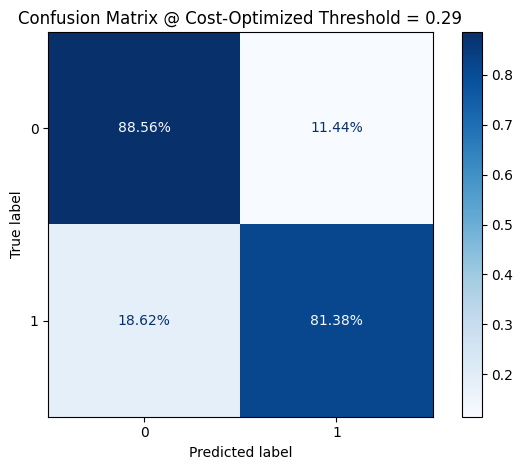

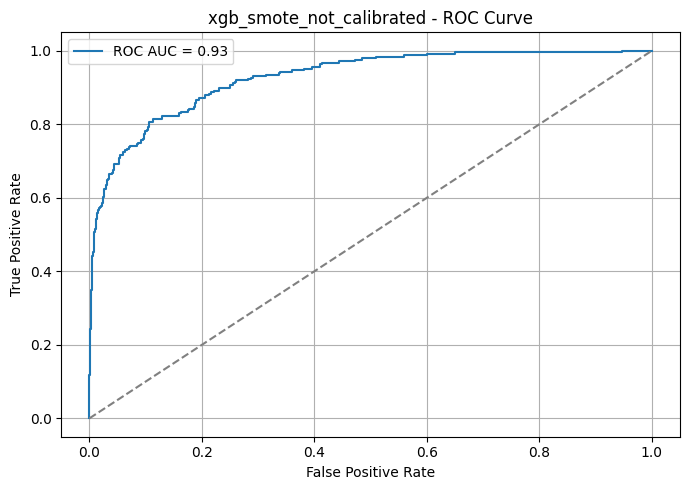

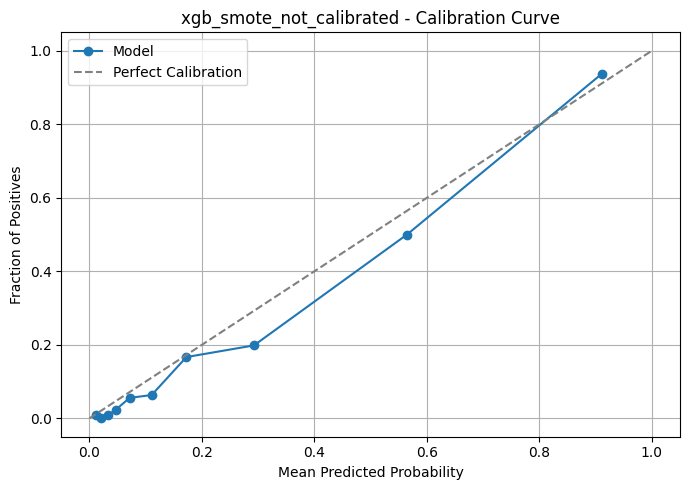

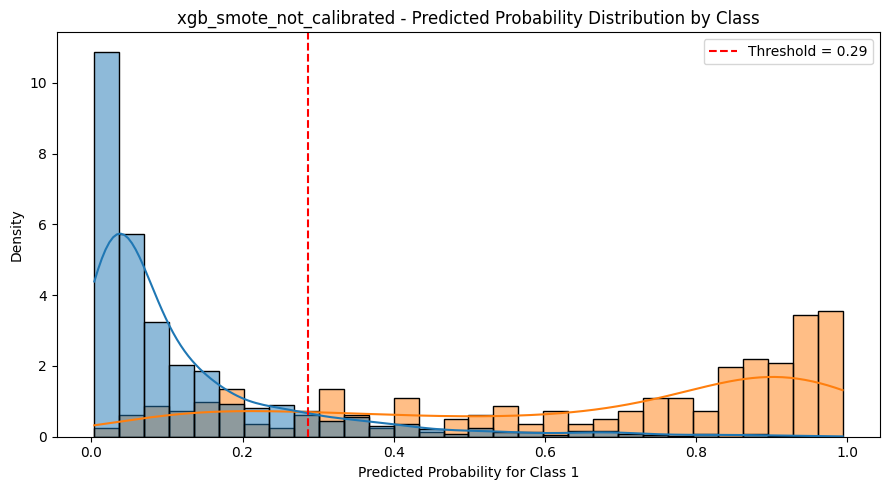


📊 Classification Report (Threshold = 0.29):
              precision    recall  f1-score   support

         0.0      0.951     0.886     0.917      1014
         1.0      0.634     0.814     0.713       247

    accuracy                          0.872      1261
   macro avg      0.793     0.850     0.815      1261
weighted avg      0.889     0.872     0.877      1261


📈 Train RMSE: 0.2316
📈 Test  RMSE: 0.2730

📉 Business Cost Evaluation for xgb_smote_not_calibrated:
🔹 Best Threshold (Cost-Optimized): 0.287
🔹 Expected Loss: 0.238  [FN cost = 4, FP cost = 1]

📊 xgb_smote_not_calibrated: Train RMSE = 0.2316, Valid RMSE = 0.2730
✅ Finished: xgb_smote_not_calibrated



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [24]:
import lib.helper_fun


# ✅ XGBoost pipeline
xgb_smote_not_calibrated = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(verbosity=0, random_state=SEED))
])
xgb_param_grid_m = {
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [4, 5],
    "model__n_estimators": [100, 200],
    "model__subsample": [0.5, 0.7, 0.8],
    "model__colsample_bytree": [0.5, 0.7, 0.8],
}

lib.helper_fun.run_model_with_gridsearch('xgb_smote_not_calibrated', xgb_smote_not_calibrated, xgb_param_grid_m, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.diagnostics, collector_non_llm,
    non_llm_features, categorical_features
)

In [26]:
collector_non_llm.get_table()

,Train RMSE,Test RMSE,Expected Loss
Logit-Baseline,0.445,0.441,0.502
Logit-non_llm,0.343,0.337,0.284
xgb_not_calibrated_no_smote,0.214,0.275,0.259
xgb_smote_not_calibrated,0.232,0.273,0.238


🔍 Running model: xgb_calibrated_no_smote


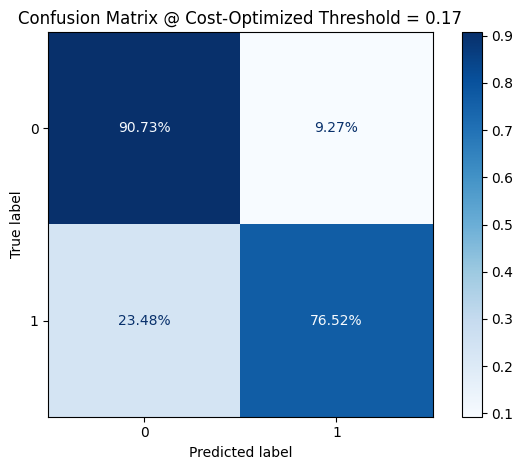

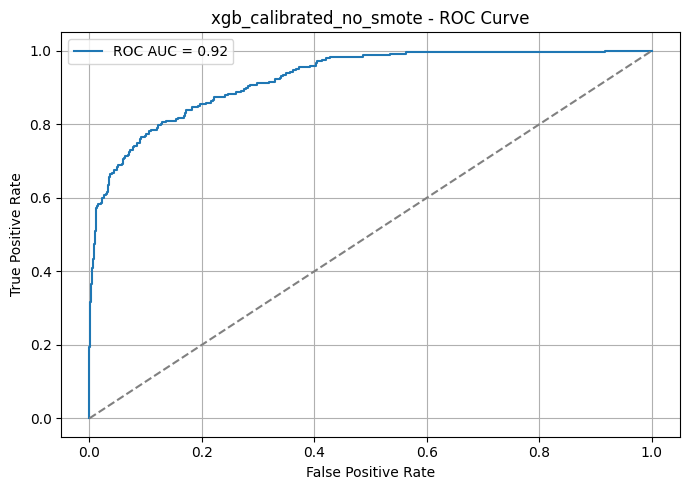

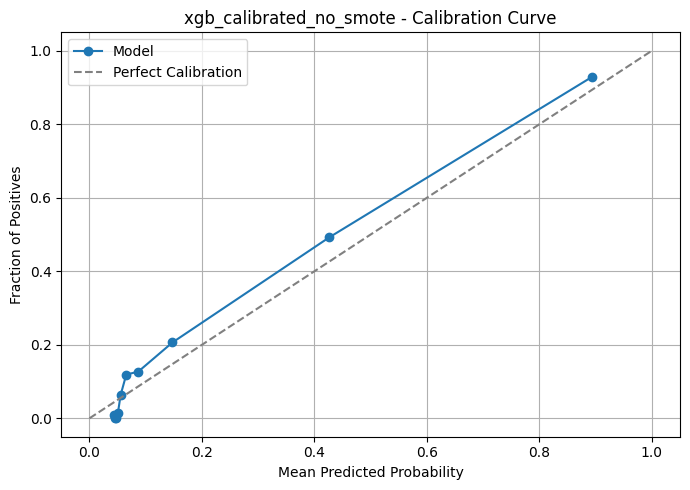

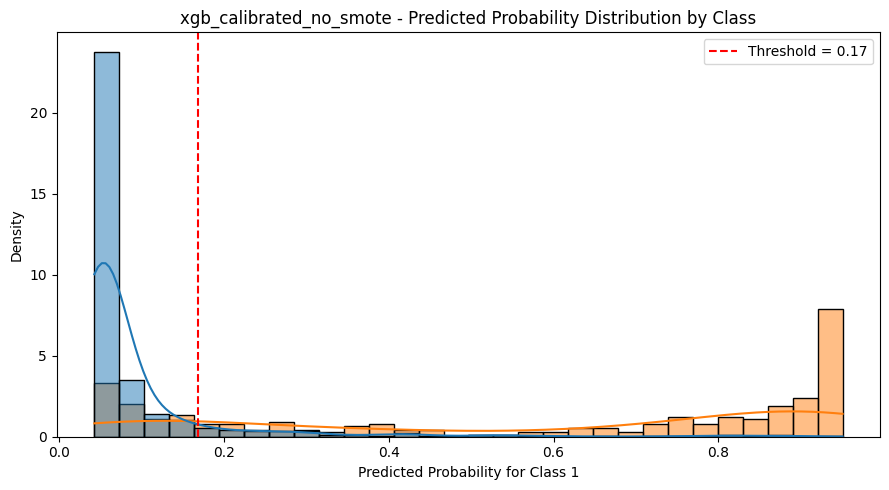


📊 Classification Report (Threshold = 0.17):
              precision    recall  f1-score   support

         0.0      0.941     0.907     0.924      1014
         1.0      0.668     0.765     0.713       247

    accuracy                          0.879      1261
   macro avg      0.804     0.836     0.818      1261
weighted avg      0.887     0.879     0.882      1261


📈 Train RMSE: 0.2374
📈 Test  RMSE: 0.2756

📉 Business Cost Evaluation for xgb_calibrated_no_smote:
🔹 Best Threshold (Cost-Optimized): 0.168
🔹 Expected Loss: 0.259  [FN cost = 4, FP cost = 1]

📊 xgb_calibrated_no_smote: Train RMSE = 0.2374, Valid RMSE = 0.2756
✅ Finished: xgb_calibrated_no_smote



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                                                                feature_weights=None,
                                                                gamma=None,
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=0.1,
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=4,
                                                                max_leaves=None,
                                                                min_child_weight=None,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=100,
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...)))])

In [27]:
xgb_no_smote_calibrated = Pipeline([
    ('calibrated_model', CalibratedClassifierCV(
        estimator=XGBClassifier(verbosity=0, random_state=SEED),
        cv=KFold(n_splits=5, shuffle=True, random_state=42)
    ))
])
xgb_param_grid0 = {
    "calibrated_model__estimator__learning_rate": [0.05, 0.1],
    "calibrated_model__estimator__max_depth": [4, 5],
    "calibrated_model__estimator__n_estimators": [100, 200],
    "calibrated_model__estimator__subsample": [0.5,0.7,0.8],
    "calibrated_model__estimator__colsample_bytree": [0.5,0.7,0.8],

}

lib.helper_fun.run_model_with_gridsearch('xgb_calibrated_no_smote', xgb_no_smote_calibrated, xgb_param_grid0, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.diagnostics, collector_non_llm,
    non_llm_features_with_publisher, categorical_features
)

### calibrated with resampling :

🔍 Running model: xgb_calibrated_smote-non_llm


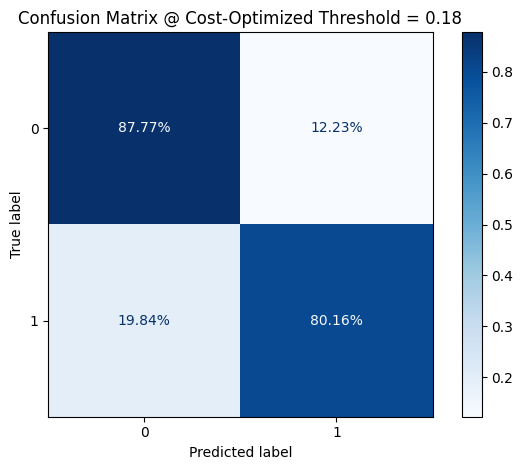


📉 Business Cost Evaluation for xgb_calibrated_smote-non_llm:
🔹 Best Threshold (Cost-Optimized): 0.178
🔹 Expected Loss: 0.254  [FN cost = 4, FP cost = 1]

📊 xgb_calibrated_smote-non_llm: Train RMSE = 0.2285, Valid RMSE = 0.2762
✅ Finished: xgb_calibrated_smote-non_llm



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                                                                feature_weights=None,
                                                                gamma=None,
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=0.05,
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=5,
                                                                max_leaves=None,
                                                                min_child_weight=None,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=200,
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...)))])

In [28]:
pipe_calibrated_xgb_smote = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('calibrated_model', CalibratedClassifierCV(estimator=XGBClassifier(verbosity=0, random_state=SEED),
                                                cv=KFold(n_splits=5, shuffle=True, random_state=42)))
])

lib.helper_fun.run_model_with_gridsearch('xgb_calibrated_smote-non_llm', pipe_calibrated_xgb_smote, xgb_param_grid0, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector_non_llm,
    non_llm_features, categorical_features
)

In [29]:
collector_non_llm.get_table()

,Train RMSE,Test RMSE,Expected Loss
Logit-Baseline,0.445,0.441,0.502
Logit-non_llm,0.343,0.337,0.284
xgb_not_calibrated_no_smote,0.214,0.275,0.259
xgb_smote_not_calibrated,0.232,0.273,0.238
xgb_calibrated_no_smote,0.237,0.276,0.259
xgb_calibrated_smote-non_llm,0.228,0.276,0.254


🔍 Running model: xgb_smote-non_llm+pub


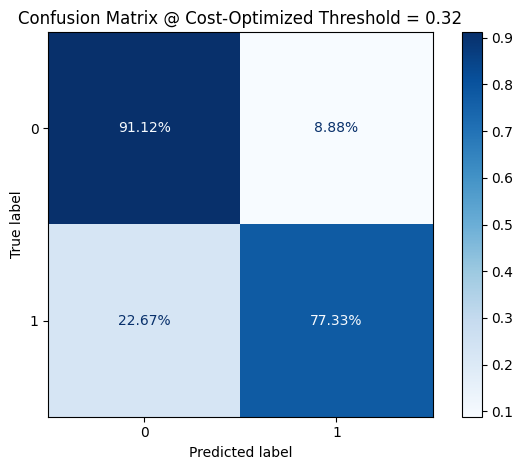


📉 Business Cost Evaluation for xgb_smote-non_llm+pub:
🔹 Best Threshold (Cost-Optimized): 0.317
🔹 Expected Loss: 0.249  [FN cost = 4, FP cost = 1]

📊 xgb_smote-non_llm+pub: Train RMSE = 0.2306, Valid RMSE = 0.2739
✅ Finished: xgb_smote-non_llm+pub



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [30]:
lib.helper_fun.run_model_with_gridsearch('xgb_smote-non_llm+pub', pipe_xgb_smote2, xgb_param_grid, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector_non_llm_pub,
    non_llm_features_with_publisher, categorical_features
)

🔍 Running model: xgb_smote-llm


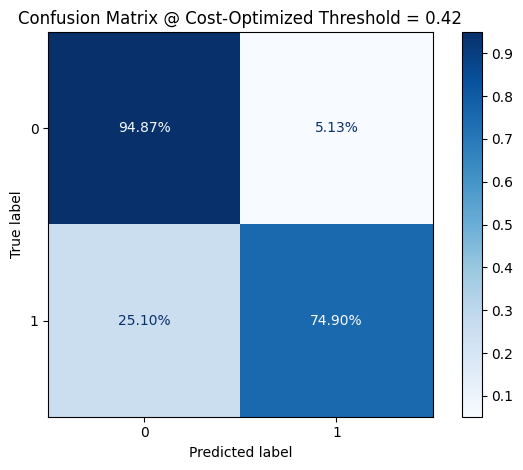


📉 Business Cost Evaluation for xgb_smote-llm:
🔹 Best Threshold (Cost-Optimized): 0.416
🔹 Expected Loss: 0.238  [FN cost = 4, FP cost = 1]

📊 xgb_smote-llm: Train RMSE = 0.2208, Valid RMSE = 0.2652
✅ Finished: xgb_smote-llm



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [31]:
lib.helper_fun.run_model_with_gridsearch('xgb_smote-llm', pipe_xgb_smote3, xgb_param_grid, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector_llm,
    all_features_full, categorical_features
)

### new_smote

🔍 Running model: xgb_new_smote-non_llm


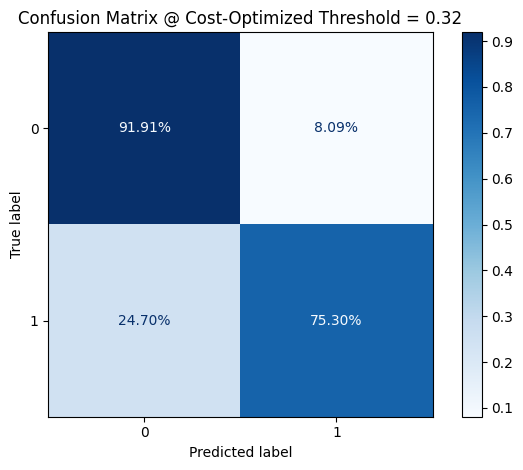


📉 Business Cost Evaluation for xgb_new_smote-non_llm:
🔹 Best Threshold (Cost-Optimized): 0.317
🔹 Expected Loss: 0.259  [FN cost = 4, FP cost = 1]

📊 xgb_new_smote-non_llm: Train RMSE = 0.2222, Valid RMSE = 0.2757
✅ Finished: xgb_new_smote-non_llm



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [32]:
lib.helper_fun.run_model_with_gridsearch('xgb_new_smote-non_llm', pipe_xgb_new_smote, xgb_param_grid, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector_non_llm,
    non_llm_features, categorical_features
)

loss = fp-cost = 1 
fn_cost = 3 

i tried with fn = 4 but that gave us more fp and i made the final decision based on theexpected loss - which was 

0.2170
vs 
0.2598
i chose the more aggresive one because the 0.04 difference results in 51 units of losss 
0.043 × 1,198 ≈ **51.5 units of cost**


▶ Choose the FN = 4 model (Threshold 0.14) if:
	•	You’re in a high-stakes environment (e.g. political campaigns, public health, fraud, etc.)
	•	Missing a true positive is significantly worse than alerting a few false ones
	•	You want to err on the side of over-detection

🔍 Running model: xgb_new_smote-non_llm+pub


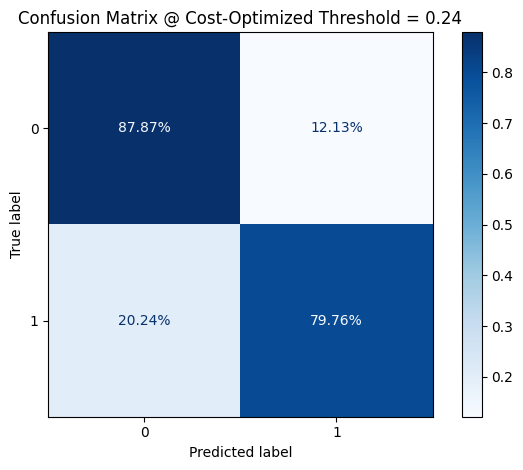


📉 Business Cost Evaluation for xgb_new_smote-non_llm+pub:
🔹 Best Threshold (Cost-Optimized): 0.238
🔹 Expected Loss: 0.256  [FN cost = 4, FP cost = 1]

📊 xgb_new_smote-non_llm+pub: Train RMSE = 0.2187, Valid RMSE = 0.2739
✅ Finished: xgb_new_smote-non_llm+pub



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [33]:
lib.helper_fun.run_model_with_gridsearch('xgb_new_smote-non_llm+pub', pipe_xgb_new_smote2, xgb_param_grid, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector_non_llm_pub,
    non_llm_features_with_publisher, categorical_features
)

🔍 Running model: xgb_new_smote-llm


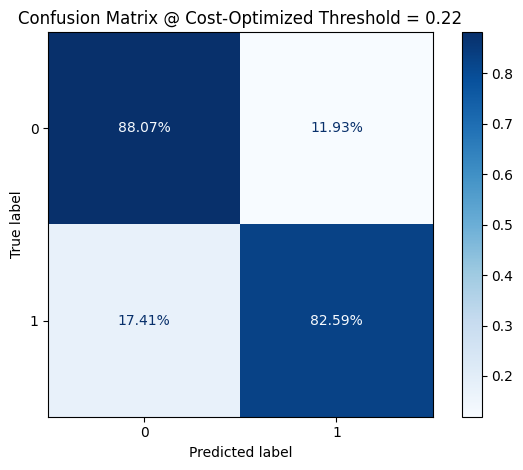


📉 Business Cost Evaluation for xgb_new_smote-llm:
🔹 Best Threshold (Cost-Optimized): 0.218
🔹 Expected Loss: 0.232  [FN cost = 4, FP cost = 1]

📊 xgb_new_smote-llm: Train RMSE = 0.2045, Valid RMSE = 0.2614
✅ Finished: xgb_new_smote-llm



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [34]:
lib.helper_fun.run_model_with_gridsearch('xgb_new_smote-llm', pipe_xgb_new_smote3, xgb_param_grid, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector_llm,
    all_features_full, categorical_features
)

### PCA

🔍 Running model: xgb_pca-non_llm


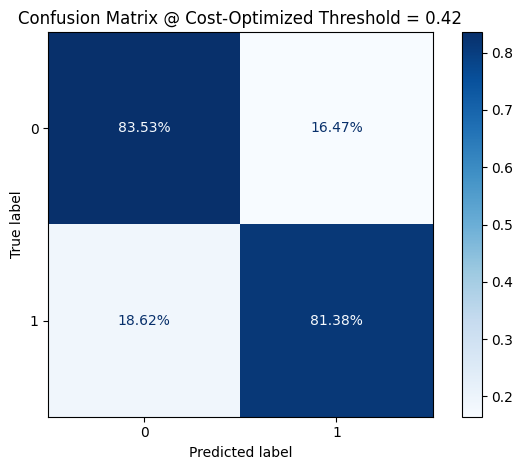


📉 Business Cost Evaluation for xgb_pca-non_llm:
🔹 Best Threshold (Cost-Optimized): 0.416
🔹 Expected Loss: 0.278  [FN cost = 4, FP cost = 1]

📊 xgb_pca-non_llm: Train RMSE = 0.2941, Valid RMSE = 0.3335
✅ Finished: xgb_pca-non_llm



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [35]:
lib.helper_fun.run_model_with_gridsearch('xgb_pca-non_llm', pipe_xgb_smote_pca, xgb_param_grid, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector_non_llm,
    non_llm_features, categorical_features
)

🔍 Running model: xgb_pca-non_llm+pub


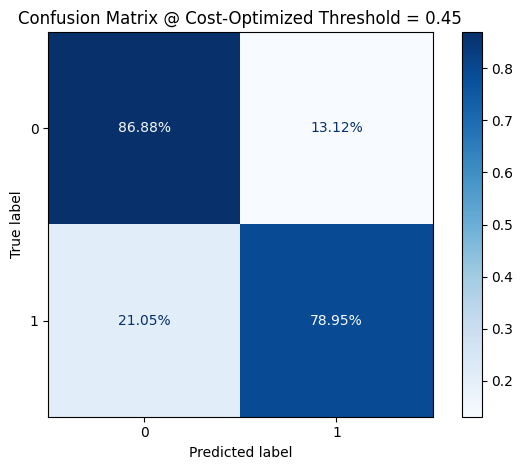


📉 Business Cost Evaluation for xgb_pca-non_llm+pub:
🔹 Best Threshold (Cost-Optimized): 0.446
🔹 Expected Loss: 0.270  [FN cost = 4, FP cost = 1]

📊 xgb_pca-non_llm+pub: Train RMSE = 0.2365, Valid RMSE = 0.3153
✅ Finished: xgb_pca-non_llm+pub



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [36]:
lib.helper_fun.run_model_with_gridsearch('xgb_pca-non_llm+pub', pipe_xgb_smote_pca2, xgb_param_grid, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector_non_llm_pub,
    non_llm_features_with_publisher, categorical_features
)

🔍 Running model: xgb_pca-llm


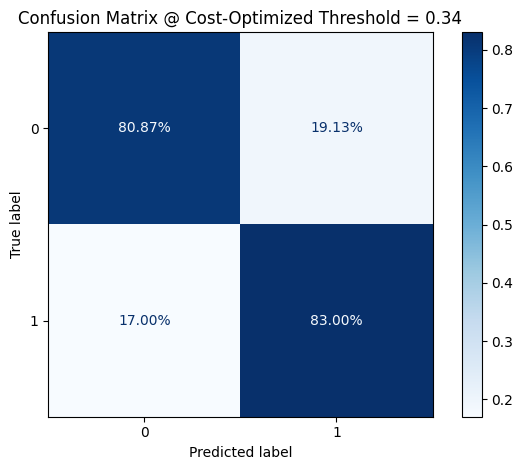


📉 Business Cost Evaluation for xgb_pca-llm:
🔹 Best Threshold (Cost-Optimized): 0.337
🔹 Expected Loss: 0.287  [FN cost = 4, FP cost = 1]

📊 xgb_pca-llm: Train RMSE = 0.2263, Valid RMSE = 0.3163
✅ Finished: xgb_pca-llm



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [37]:
lib.helper_fun.run_model_with_gridsearch('xgb_pca-llm', pipe_xgb_smote_pca3, xgb_param_grid, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector_llm,
    all_features_full, categorical_features
)

### select

🔍 Running model: xgb_select-non_llm


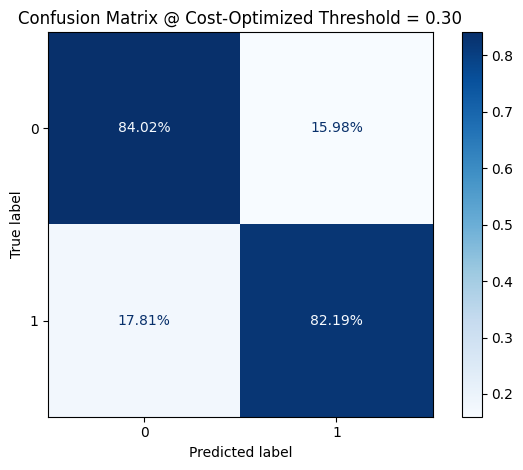


📉 Business Cost Evaluation for xgb_select-non_llm:
🔹 Best Threshold (Cost-Optimized): 0.297
🔹 Expected Loss: 0.268  [FN cost = 4, FP cost = 1]

📊 xgb_select-non_llm: Train RMSE = 0.2701, Valid RMSE = 0.3014
✅ Finished: xgb_select-non_llm



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [39]:
lib.helper_fun.run_model_with_gridsearch('xgb_select-non_llm', pipe_xgb_select_features, xgb_param_grid, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector_non_llm,
    non_llm_features, categorical_features
)

🔍 Running model: xgb_select-non_llm+pub


/Users/ghadena/Desktop/geopol/.venv/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [31 32] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/ghadena/Desktop/geopol/.venv/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/Users/ghadena/Desktop/geopol/.venv/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [31 32] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/ghadena/Desktop/geopol/.venv/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/Users/ghadena/Desktop/geopol/.venv/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWar

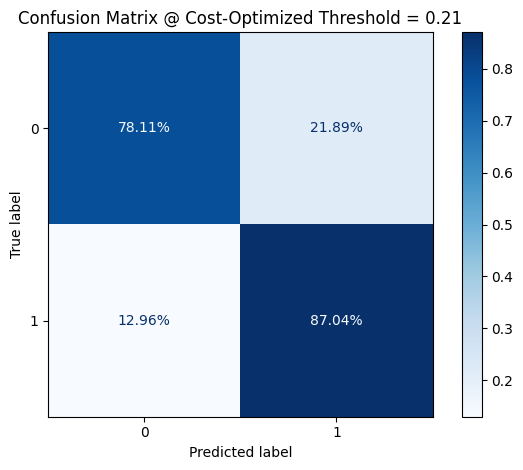


📉 Business Cost Evaluation for xgb_select-non_llm+pub:
🔹 Best Threshold (Cost-Optimized): 0.208
🔹 Expected Loss: 0.278  [FN cost = 4, FP cost = 1]

📊 xgb_select-non_llm+pub: Train RMSE = 0.2510, Valid RMSE = 0.2901
✅ Finished: xgb_select-non_llm+pub



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [40]:
lib.helper_fun.run_model_with_gridsearch('xgb_select-non_llm+pub', pipe_xgb_select_features2, xgb_param_grid, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector_non_llm_pub,
    non_llm_features_with_publisher, categorical_features
)

🔍 Running model: xgb_select-llm


/Users/ghadena/Desktop/geopol/.venv/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [42 43] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/ghadena/Desktop/geopol/.venv/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/Users/ghadena/Desktop/geopol/.venv/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [42 43] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/ghadena/Desktop/geopol/.venv/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/Users/ghadena/Desktop/geopol/.venv/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWar

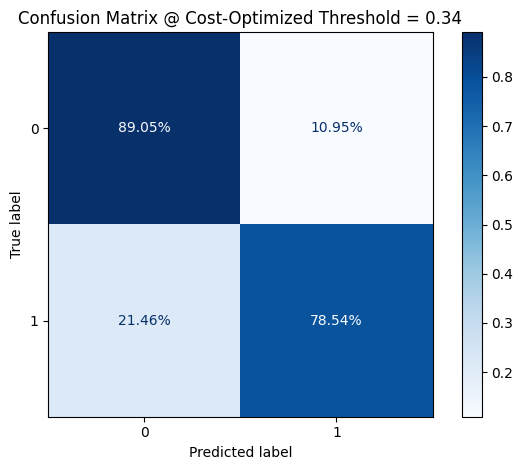


📉 Business Cost Evaluation for xgb_select-llm:
🔹 Best Threshold (Cost-Optimized): 0.337
🔹 Expected Loss: 0.256  [FN cost = 4, FP cost = 1]

📊 xgb_select-llm: Train RMSE = 0.2497, Valid RMSE = 0.2786
✅ Finished: xgb_select-llm



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [41]:
lib.helper_fun.run_model_with_gridsearch('xgb_select-llm', pipe_xgb_select_features3, xgb_param_grid, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector_llm,
    all_features_full, categorical_features
)

In [42]:
collector_non_llm.get_table()


,Train RMSE,Test RMSE,Expected Loss
Logit-Baseline,0.445,0.441,0.502
Logit-non_llm,0.343,0.337,0.284
xgb_not_calibrated_no_smote,0.214,0.275,0.259
xgb_smote_not_calibrated,0.232,0.273,0.238
xgb_calibrated_no_smote,0.237,0.276,0.259
xgb_calibrated_smote-non_llm,0.228,0.276,0.254
xgb_new_smote-non_llm,0.222,0.276,0.259
xgb_pca-non_llm,0.294,0.334,0.278
xgb_select-non_llm,0.270,0.301,0.268


In [43]:
collector_non_llm_pub.get_table()

,Train RMSE,Test RMSE,Expected Loss
Logit-non_llm+pub,0.344,0.337,0.282
xgb_smote-non_llm+pub,0.231,0.274,0.249
xgb_new_smote-non_llm+pub,0.219,0.274,0.256
xgb_pca-non_llm+pub,0.237,0.315,0.270
xgb_select-non_llm+pub,0.251,0.290,0.278


In [44]:
collector_llm.get_table()

,Train RMSE,Test RMSE,Expected Loss
Logit-llm,0.332,0.329,0.262
xgb_smote-llm,0.221,0.265,0.238
xgb_new_smote-llm,0.204,0.261,0.232
xgb_pca-llm,0.226,0.316,0.287
xgb_select-llm,0.250,0.279,0.256


## catboost 

In [76]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

preprocessor_cat = ColumnTransformer([
    ('num', StandardScaler(), [f for f in non_llm_features if f not in categorical_features])
    # NO OneHotEncoder here
])

pipe_cat = ImbPipeline([
    ('preprocessor', preprocessor_cat),
    ('smote', SMOTE(random_state=42)),
    ('model', CatBoostClassifier(
        cat_features=categorical_features,  # This is OK now
        random_state=SEED,
        verbose=0
    ))
])

In [77]:
lib.helper_fun.run_model_with_gridsearch('cat-non_llm', pipe_cat, catboost_param_grid, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector_non_llm,
    non_llm_features, categorical_features
)

🔍 Running model: cat-non_llm
First fit failed, likely due to early_stopping_rounds not supported: 
All the 160 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
160 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/ghadena/Desktop/geopol/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/ghadena/Desktop/geopol/.venv/lib/python3.13/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/Users/ghadena/Desktop/geopol/.venv/lib/python3.13/site-packages/imblearn/pipeline.py", line 526, in fit
    self._final_estimator.fit(Xt, yt, **l

AttributeError: 'GridSearchCV' object has no attribute 'best_estimator_'

In [64]:
lib.helper_fun.run_model_with_gridsearch('cat-llm', pipe_cat2, catboost_param_grid, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector_llm,
    all_features_full, categorical_features
)

🔍 Running model: cat-llm


ValueError: 
All the 160 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
160 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/ghadena/Desktop/geopol/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/ghadena/Desktop/geopol/.venv/lib/python3.13/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/Users/ghadena/Desktop/geopol/.venv/lib/python3.13/site-packages/imblearn/pipeline.py", line 517, in fit
    routed_params = self._check_method_params(method="fit", props=params)
  File "/Users/ghadena/Desktop/geopol/.venv/lib/pytho

In [ ]:
collector_non_llm.get_table()

# overfitting --- > trying LASSO and ridge 

In [59]:
pipe_xgb_smote5 = clone(pipe_xgb_smote)
pipe_xgb_smote4 = clone(pipe_xgb_smote)
pipe_xgb_smote_pca4 = clone(pipe_xgb_smote_pca)
pipe_xgb_select_features4 =clone(pipe_xgb_select_features)
pipe_xgb_new_smote4 = clone(pipe_xgb_new_smote)

xgb_param_grid2 = {
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [4, 5],
    "model__n_estimators": [100, 200],
    "model__subsample": [0.5, 0.7, 0.8],
    "model__colsample_bytree": [0.5, 0.7, 0.8],
    "model__reg_alpha": [0, 1],            
    "model__reg_lambda": [1, 5, 10],
}

🔍 Running model: xgb_smote-non_llm-betterGS


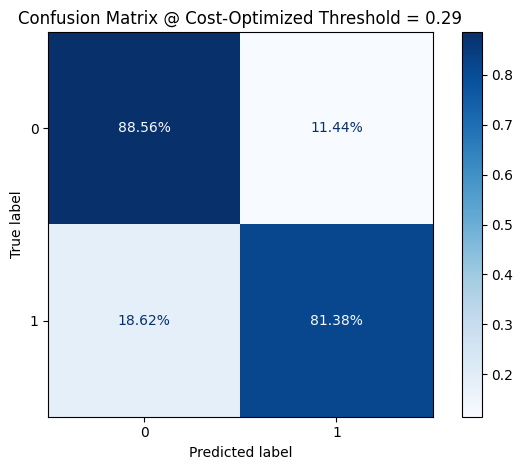


📉 Business Cost Evaluation for xgb_smote-non_llm-betterGS:
🔹 Best Threshold (Cost-Optimized): 0.287
🔹 Expected Loss: 0.238  [FN cost = 4, FP cost = 1]

📊 xgb_smote-non_llm-betterGS: Train RMSE = 0.2316, Valid RMSE = 0.2730
✅ Finished: xgb_smote-non_llm-betterGS



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [55]:
lib.helper_fun.run_model_with_gridsearch('xgb_smote-non_llm-betterGS', pipe_xgb_smote4, xgb_param_grid2, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector_non_llm,
    non_llm_features, categorical_features
)

🔍 Running model: xgb_new_smote-non_llm-betterGS


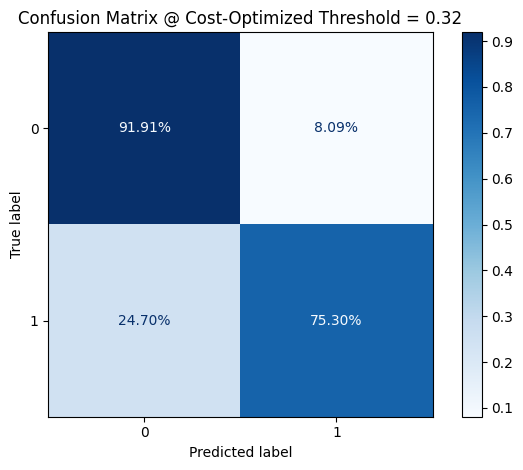


📉 Business Cost Evaluation for xgb_new_smote-non_llm-betterGS:
🔹 Best Threshold (Cost-Optimized): 0.317
🔹 Expected Loss: 0.259  [FN cost = 4, FP cost = 1]

📊 xgb_new_smote-non_llm-betterGS: Train RMSE = 0.2222, Valid RMSE = 0.2757
✅ Finished: xgb_new_smote-non_llm-betterGS



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [56]:
lib.helper_fun.run_model_with_gridsearch('xgb_new_smote-non_llm-betterGS', pipe_xgb_new_smote4, xgb_param_grid2, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector_non_llm,
    non_llm_features, categorical_features
)

🔍 Running model: xgb_pca-non_llm-betterGS


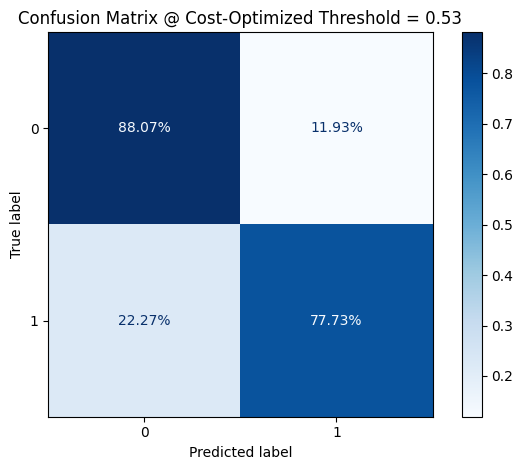


📉 Business Cost Evaluation for xgb_pca-non_llm-betterGS:
🔹 Best Threshold (Cost-Optimized): 0.535
🔹 Expected Loss: 0.270  [FN cost = 4, FP cost = 1]

📊 xgb_pca-non_llm-betterGS: Train RMSE = 0.3134, Valid RMSE = 0.3399
✅ Finished: xgb_pca-non_llm-betterGS



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [60]:
lib.helper_fun.run_model_with_gridsearch('xgb_pca-non_llm-betterGS', pipe_xgb_smote_pca4, xgb_param_grid2, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector_non_llm,
    non_llm_features, categorical_features
)

🔍 Running model: xgb_select-non_llm-betterGS


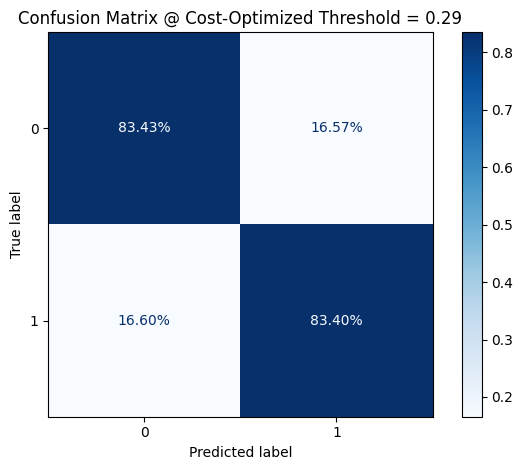


📉 Business Cost Evaluation for xgb_select-non_llm-betterGS:
🔹 Best Threshold (Cost-Optimized): 0.287
🔹 Expected Loss: 0.263  [FN cost = 4, FP cost = 1]

📊 xgb_select-non_llm-betterGS: Train RMSE = 0.2777, Valid RMSE = 0.3012
✅ Finished: xgb_select-non_llm-betterGS



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [61]:
lib.helper_fun.run_model_with_gridsearch('xgb_select-non_llm-betterGS', pipe_xgb_select_features4, xgb_param_grid2, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector_non_llm,
    non_llm_features, categorical_features
)

In [498]:
#collector.get_table()

🔍 Running model: xgb_smote-llm-betterGS


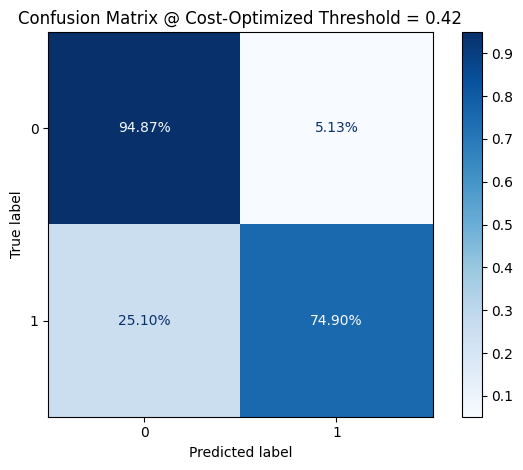


📉 Business Cost Evaluation for xgb_smote-llm-betterGS:
🔹 Best Threshold (Cost-Optimized): 0.416
🔹 Expected Loss: 0.238  [FN cost = 4, FP cost = 1]

📊 xgb_smote-llm-betterGS: Train RMSE = 0.2208, Valid RMSE = 0.2652
✅ Finished: xgb_smote-llm-betterGS



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [62]:
lib.helper_fun.run_model_with_gridsearch('xgb_smote-llm-betterGS', pipe_xgb_smote5, xgb_param_grid2, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector_llm,
    all_features_full, categorical_features
)

### ❗ Why PCA and Feature Selection Did Not Improve Model Performance

Despite the intention to reduce overfitting by applying PCA or feature selection, the models still overfit or underperformed. Here's why:

- **Dimensionality reduction is not always beneficial**:
  - PCA removes low-variance features without considering their relationship to the target.
  - Feature selection (e.g., SelectKBest) may discard weak but informative signals.

- **PCA + Regularization may oversimplify the model**:
  - PCA already reduces feature dimensionality.
  - Adding `reg_alpha` (L1) or `reg_lambda` (L2) can further shrink the model, potentially removing too much useful signal.
  - This can lead to underfitting, especially when the remaining features are too compressed or filtered.

- **Tree-based models like XGBoost do not benefit from PCA**:
  - XGBoost handles multicollinearity well.
  - It inherently performs feature selection via split criteria.
  - Applying PCA or feature filtering may reduce its ability to model complex interactions.

- **Empirical results confirm this**:
  - Models with the **full feature set and regularization** performed better than those with PCA or SelectKBest.
  - Example: `xgb_smote-non_llm+pub` had lower Expected Loss than `xgb_select-*` or `xgb_pca-*` versions, even with the same grid search.

### ✅ Key Takeaway

For XGBoost, it is often better to:
- Use the full (cleaned) feature set.
- Apply **regularization** (`reg_alpha`, `reg_lambda`, `min_child_weight`, `gamma`) to control complexity.
- Avoid aggressive dimensionality reduction unless guided by SHAP or feature importance.


### ❗ Why `xgb_smote-llm-betterGS` Still Shows Overfitting

- **LLM-derived features are high signal but risky**: They often capture semantic patterns that don’t fully generalize, even if they’re few.
- **Train–Test RMSE gap remains** (+0.111), despite applying strong regularization (`reg_alpha`, `reg_lambda`, `min_child_weight`, `gamma`).
- The dataset is still relatively small (~4,789 rows), and XGBoost can memorize patterns when boosted.
- Even a small number of strong features can dominate splits and inflate training performance.
- Further regularization may help reduce the gap, but risks increasing Expected Loss (i.e., underfitting).
- RMSE penalizes larger errors more heavily, so small mispredictions on the test set can have a big impact.

### ✅ Takeaway

This model is already much better than earlier versions, and the remaining overfitting is expected due to the nature of the data and the power of LLM features. Consider ensemble averaging or bagging if further stability is needed.

# results - rmse tables 

In [80]:
collector_non_llm.get_table()

,Train RMSE,Test RMSE,Expected Loss
Logit-Baseline,0.445,0.441,0.502
Logit-non_llm,0.343,0.337,0.284
xgb_not_calibrated_no_smote,0.214,0.275,0.259
xgb_smote_not_calibrated,0.232,0.273,0.238
xgb_calibrated_no_smote,0.237,0.276,0.259
xgb_calibrated_smote-non_llm,0.228,0.276,0.254
xgb_new_smote-non_llm,0.222,0.276,0.259
xgb_pca-non_llm,0.294,0.334,0.278
xgb_select-non_llm,0.270,0.301,0.268
xgb_smote-non_llm-betterGS,0.232,0.273,0.238


In [81]:
collector_non_llm_pub.get_table()

,Train RMSE,Test RMSE,Expected Loss
Logit-non_llm+pub,0.344,0.337,0.282
xgb_smote-non_llm+pub,0.231,0.274,0.249
xgb_new_smote-non_llm+pub,0.219,0.274,0.256
xgb_pca-non_llm+pub,0.237,0.315,0.270
xgb_select-non_llm+pub,0.251,0.290,0.278
rf-non_llm+pub,0.210,0.293,0.259


In [82]:
collector_llm.get_table()

,Train RMSE,Test RMSE,Expected Loss
Logit-llm,0.332,0.329,0.262
xgb_smote-llm,0.221,0.265,0.238
xgb_new_smote-llm,0.204,0.261,0.232
xgb_pca-llm,0.226,0.316,0.287
xgb_select-llm,0.250,0.279,0.256
xgb_smote-llm-betterGS,0.221,0.265,0.238
rf-llm,0.147,0.280,0.234


# Diagonsitics on the best performing model 

In [125]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Best model pipeline (already fitted)
xgb_model = best_models['xgb_smote_not_calibrated']


# 1️⃣ Get the calibrated XGBoost estimator
final_step_name = list(xgb_model.named_steps.keys())[-1]
final_estimator = xgb_model.named_steps[final_step_name]
# 2️⃣ Get predicted probabilities
train_probs = xgb_model.predict_proba(X_train)[:, 1]
valid_probs = xgb_model.predict_proba(X_valid)[:, 1]

# 3️⃣ Get predicted labels based on 0.5 threshold (or your custom threshold)
y_train_pred = (train_probs >= 0.18).astype(int)
y_valid_pred = (valid_probs >= 0.18).astype(int)

# ✅ Now you can run your diagnostics function
# Example:
# diagnostics(y_train, train_probs, y_train_pred, y_valid, valid_probs, y_valid_pred)

## diagnostics - confusion matrix, roc curve, calibration curve, precision recall curve ,prob distribution, classification report, rmse, prediction confidence by correctness 

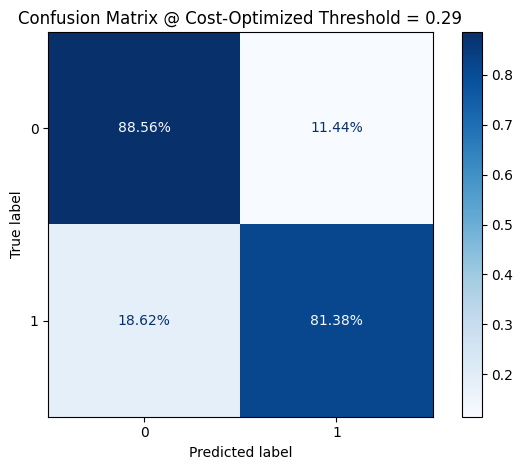

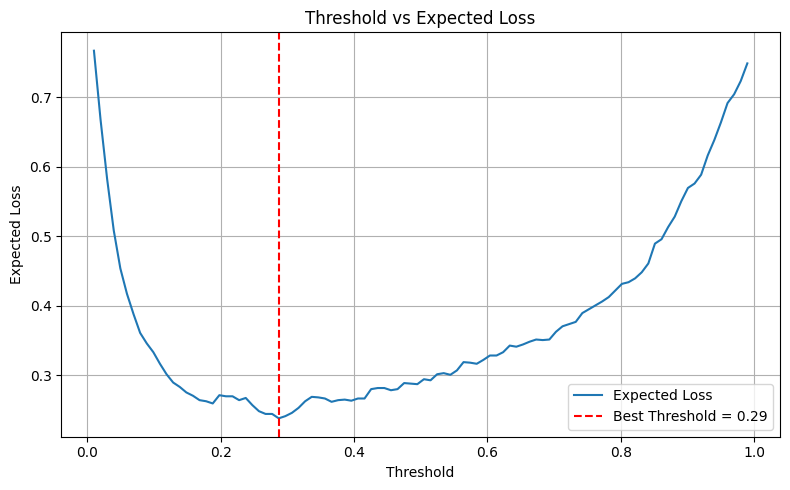

(0.287, array([0, 1, 0, ..., 0, 0, 0], shape=(1261,)))

In [131]:
lib.helper_fun.matrix(y_train, train_probs, y_valid, valid_probs, model_name="best_xgb", show_threshold_plot=True)

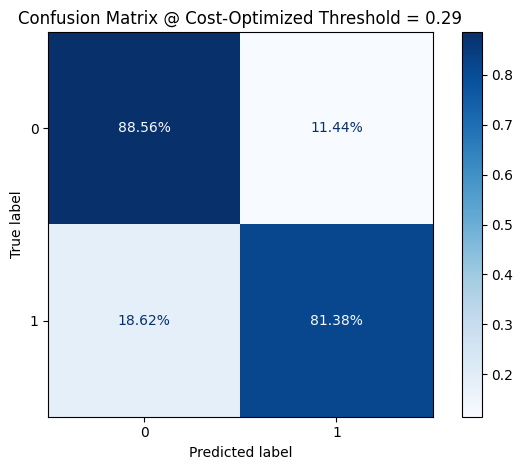

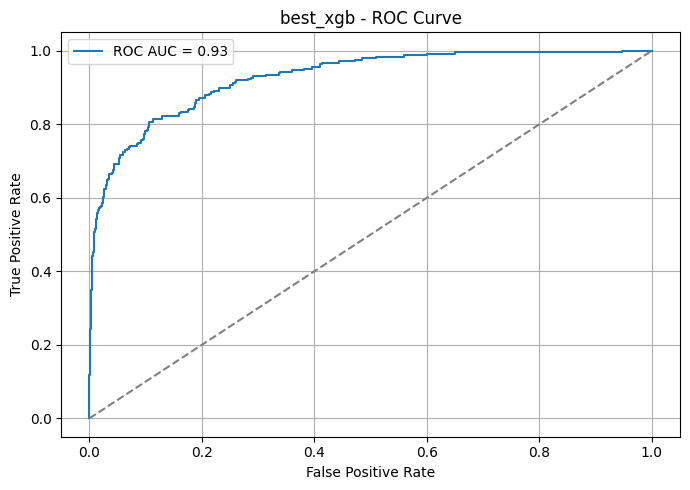

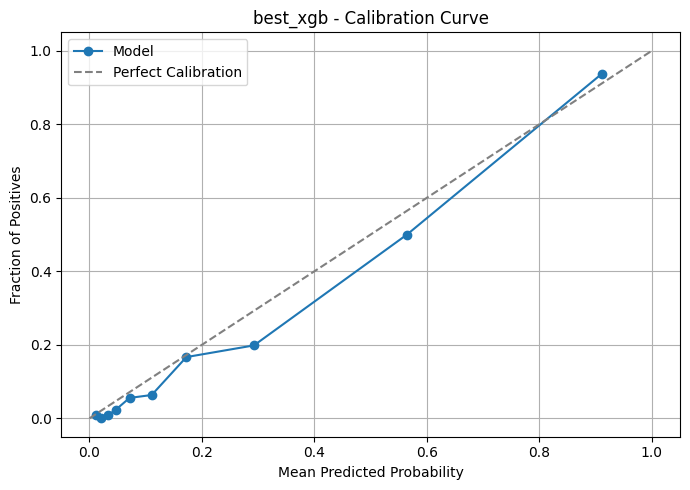

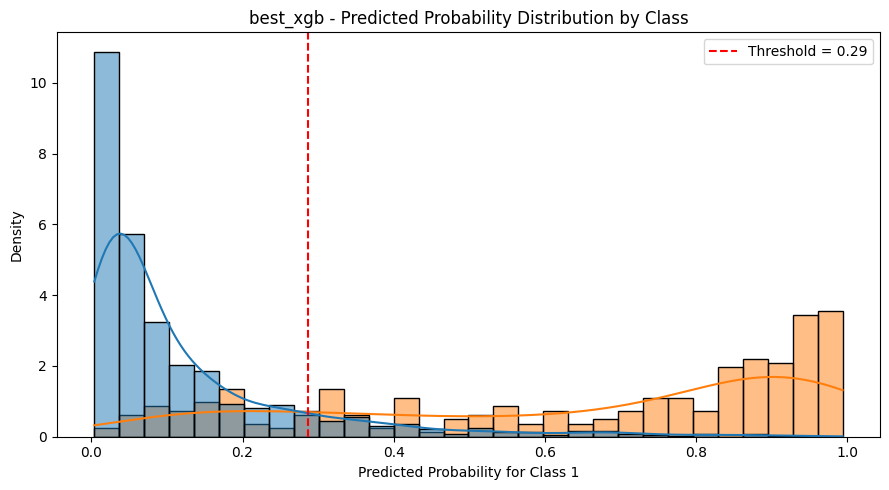


📊 Classification Report (Threshold = 0.29):
              precision    recall  f1-score   support

         0.0      0.951     0.886     0.917      1014
         1.0      0.634     0.814     0.713       247

    accuracy                          0.872      1261
   macro avg      0.793     0.850     0.815      1261
weighted avg      0.889     0.872     0.877      1261


📈 Train RMSE: 0.2316
📈 Test  RMSE: 0.2730


{'Model': 'best_xgb',
 'Threshold': 0.287,
 'Train RMSE': 0.232,
 'Test RMSE': 0.273,
 'AUC': 0.927}

In [132]:
lib.helper_fun.diagnostics(y_train, train_probs, y_valid, valid_probs, model_name="best_xgb")

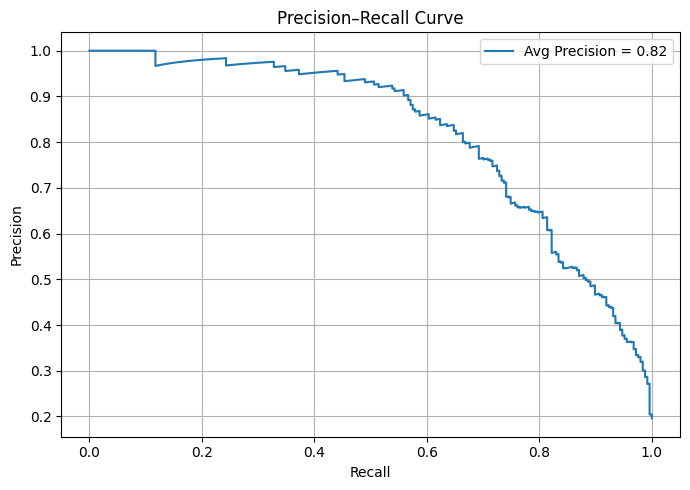

In [133]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_valid, valid_probs)
avg_precision = average_precision_score(y_valid, valid_probs)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"Avg Precision = {avg_precision:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Prediction Confidence by Correctness')

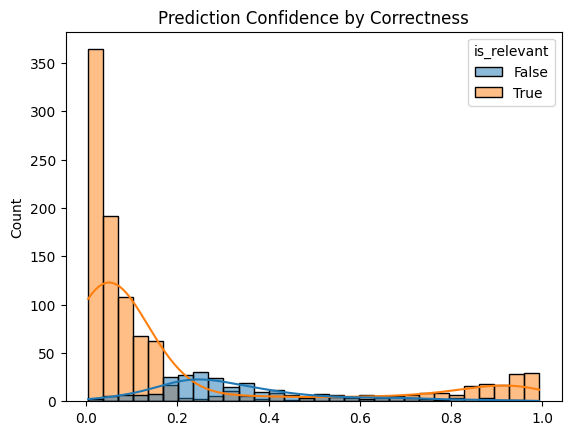

In [134]:
y_pred = (valid_probs >=  0.178).astype(int)

sns.histplot(x=valid_probs, hue=(y_valid == y_pred), bins=30, kde=True)
plt.title("Prediction Confidence by Correctness")

## feature importance (Shap) with fragility tests 

In [135]:
#final_estimator = xgb_model.named_steps['calibrated_model'].calibrated_classifiers_[0].estimator
X_enc_valid = xgb_model.named_steps['preprocessor'].transform(X_valid)

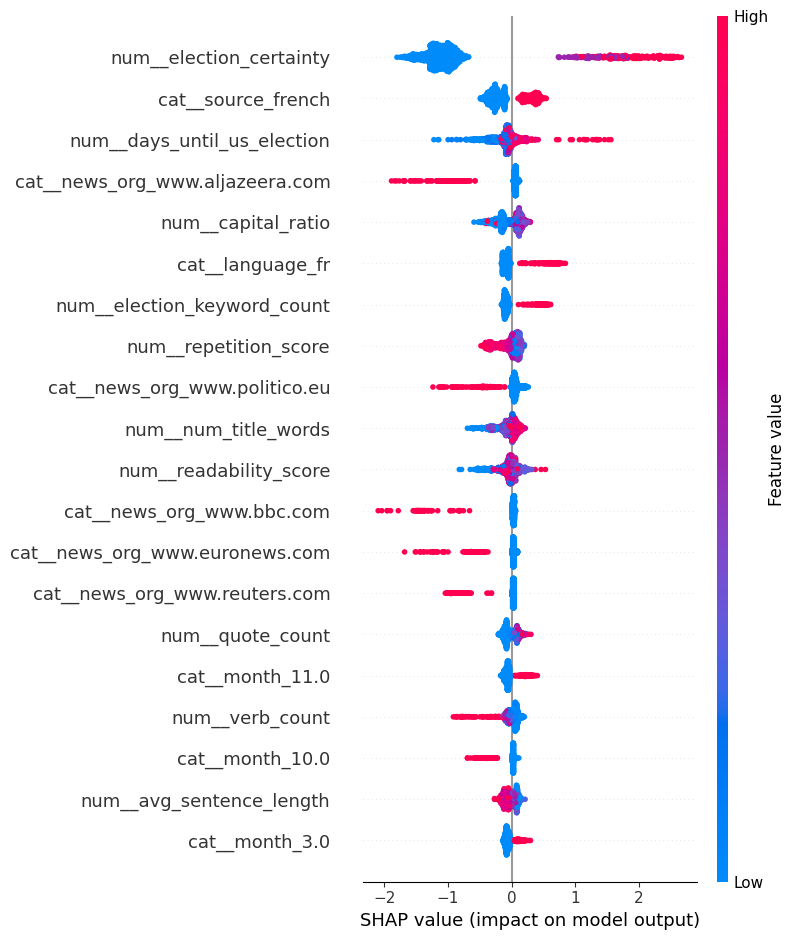

In [136]:
import shap

explainer = shap.TreeExplainer(final_estimator)
shap_values = explainer.shap_values(X_enc_valid)

# Summary plot
shap.summary_plot(shap_values, X_enc_valid, 
                  feature_names=xgb_model.named_steps['preprocessor'].get_feature_names_out(),
                  max_display=20)

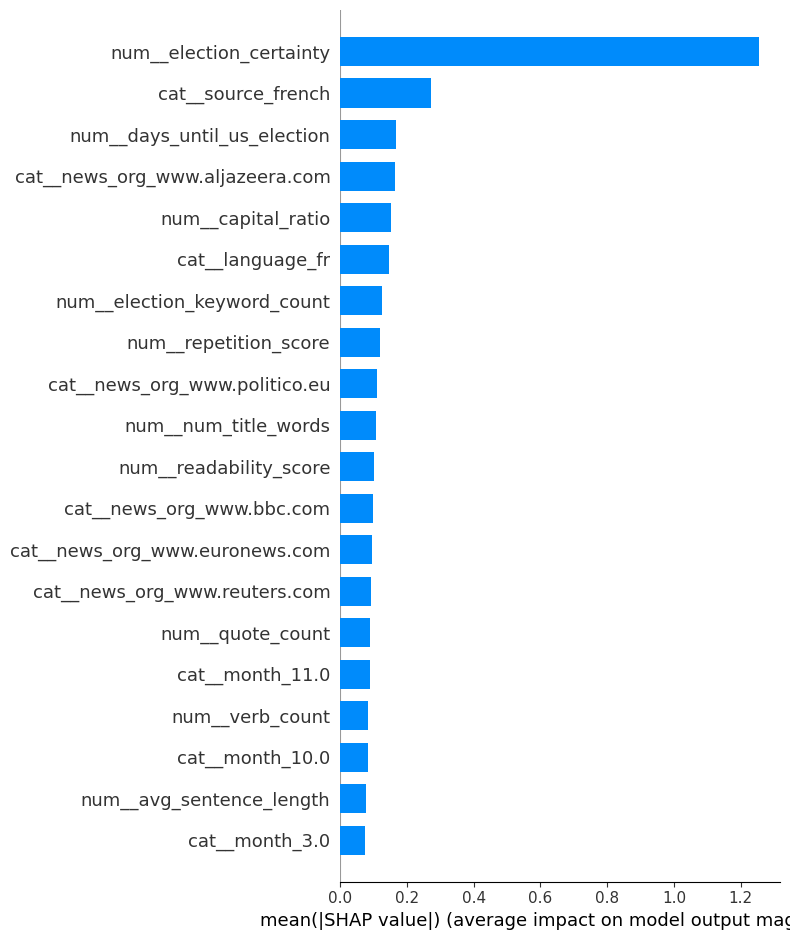

In [137]:
encoded_feature_names = xgb_model.named_steps['preprocessor'].get_feature_names_out()
shap.summary_plot(shap_values, X_enc_valid, feature_names=encoded_feature_names, plot_type="bar")

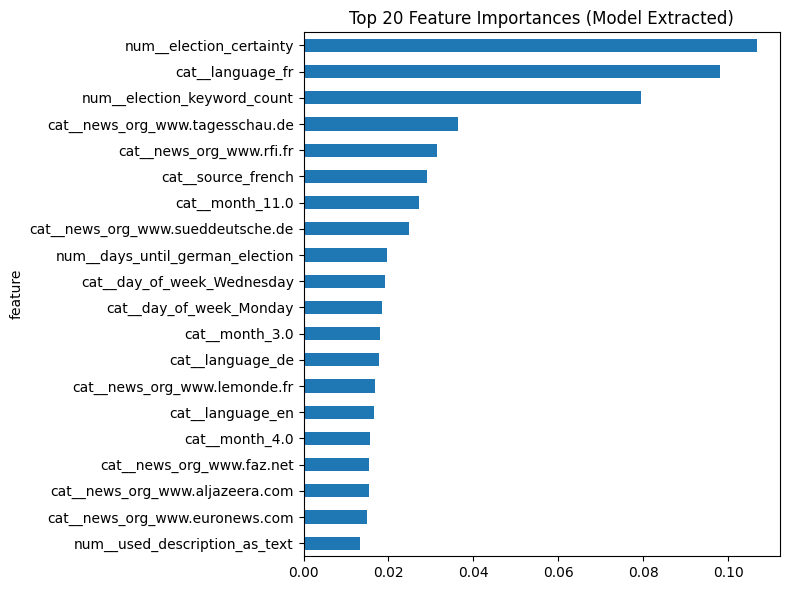

In [138]:
#final_estimator = xgb_model.named_steps['calibrated_model'].calibrated_classifiers_[0].estimator
importances = final_estimator.feature_importances_

# Create and plot
feat_imp_df = pd.DataFrame({
    'feature': encoded_feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feat_imp_df.head(20).plot.barh(x='feature', y='importance', figsize=(8, 6), legend=False)
plt.title("Top 20 Feature Importances (Model Extracted)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

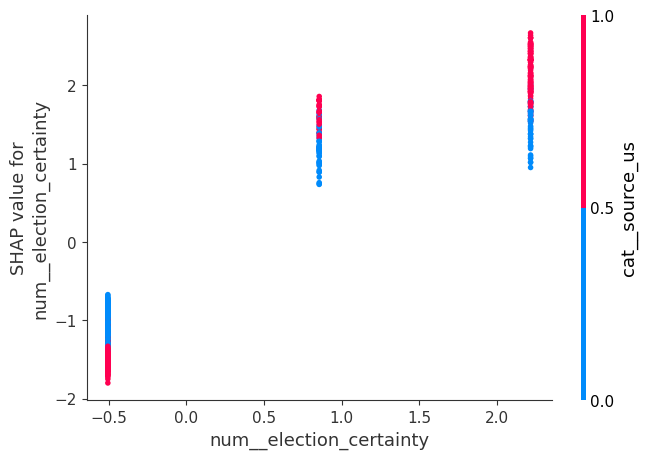

In [105]:
shap.dependence_plot("num__election_certainty", shap_values, X_enc_valid, feature_names=encoded_feature_names)

### fragility test

🔍 Running model: xgb_smote-fragile


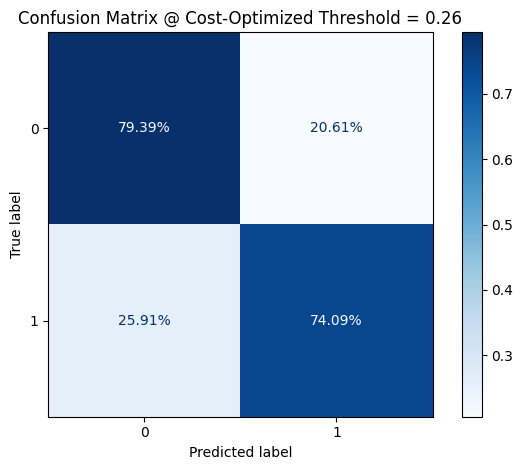

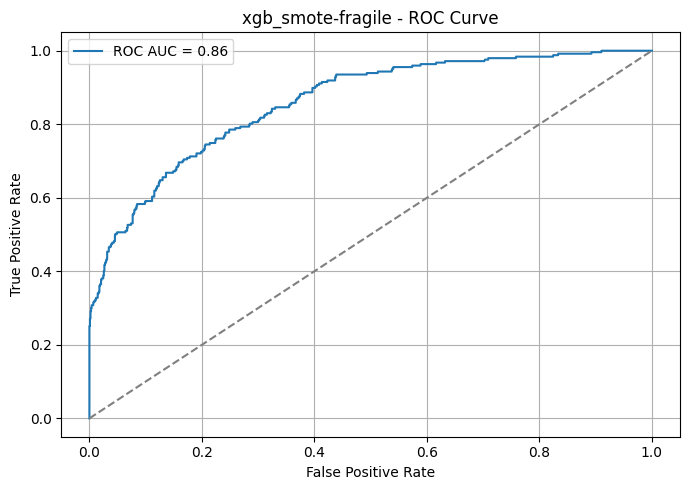

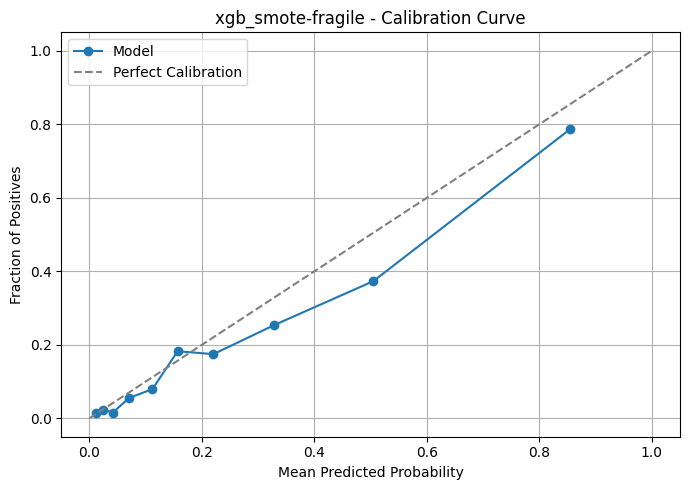

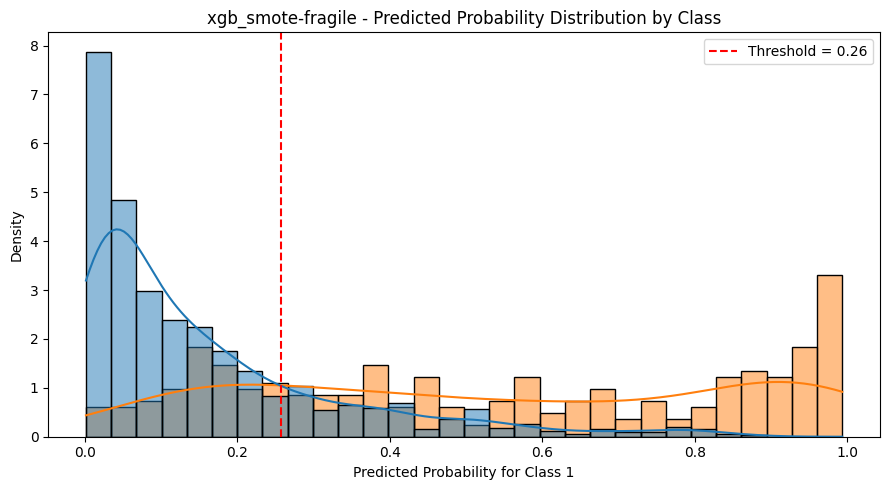


📊 Classification Report (Threshold = 0.26):
              precision    recall  f1-score   support

         0.0      0.926     0.794     0.855      1014
         1.0      0.467     0.741     0.573       247

    accuracy                          0.784      1261
   macro avg      0.697     0.767     0.714      1261
weighted avg      0.836     0.784     0.800      1261


📈 Train RMSE: 0.2596
📈 Test  RMSE: 0.3236

📉 Business Cost Evaluation for xgb_smote-fragile:
🔹 Best Threshold (Cost-Optimized): 0.257
🔹 Expected Loss: 0.369  [FN cost = 4, FP cost = 1]

📊 xgb_smote-fragile: Train RMSE = 0.2596, Valid RMSE = 0.3236
✅ Finished: xgb_smote-fragile



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [139]:
fragile_feature_list = [
    col for col in non_llm_features if col != 'election_certainty'
]

# ✅ XGBoost pipeline
pipe_xgb_fragile = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(verbosity=0, random_state=SEED))
])


lib.helper_fun.run_model_with_gridsearch('xgb_smote-fragile', pipe_xgb_fragile, xgb_param_grid, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.diagnostics, collector_non_llm,
    fragile_feature_list, categorical_features
)

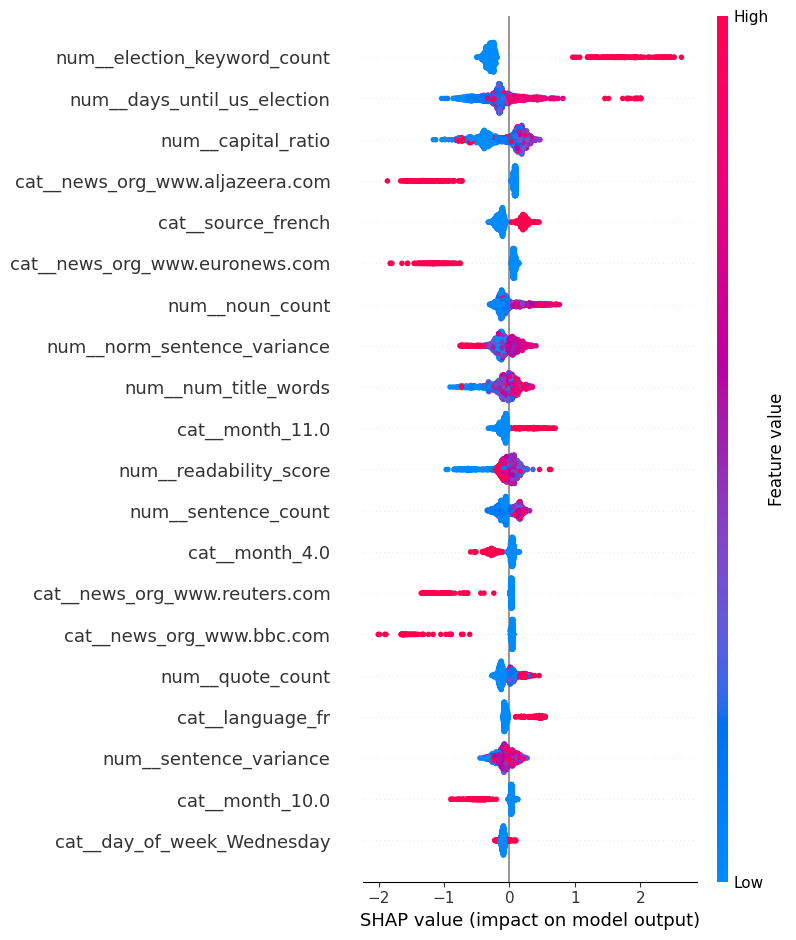

In [140]:
fragile_model = best_models['xgb_smote-fragile']

final_estimatorf1 = fragile_model.named_steps['model']
encoded_feature_names = fragile_model.named_steps['preprocessor'].get_feature_names_out()


explainer = shap.TreeExplainer(final_estimatorf1)
X_valid_processed = fragile_model.named_steps['preprocessor'].transform(X_valid[fragile_feature_list])
shap_values = explainer.shap_values(X_valid_processed)

shap.summary_plot(shap_values, X_valid_processed, feature_names=encoded_feature_names)

### fragility test 2 

🔍 Running model: xgb_smote-fragile2


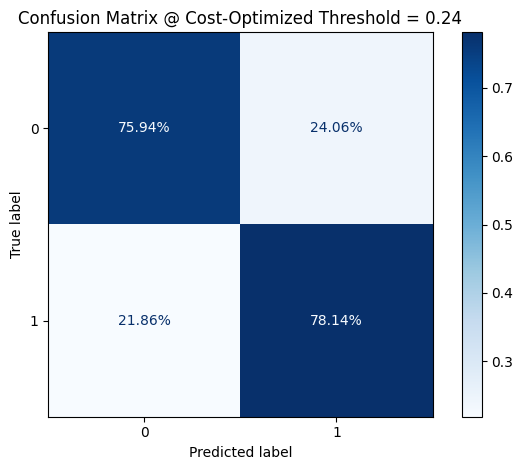

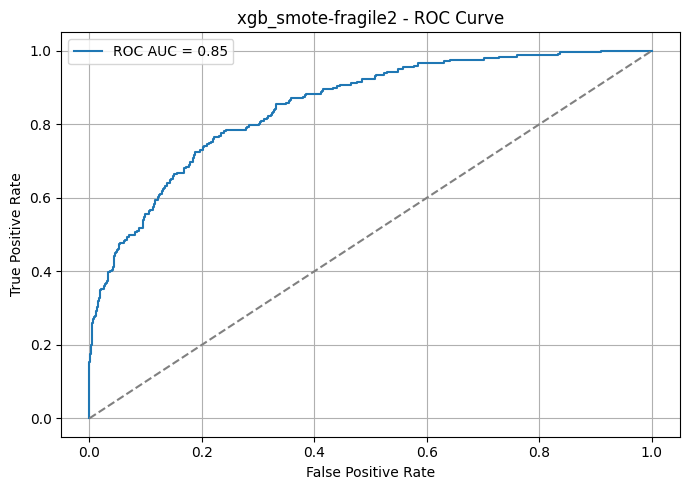

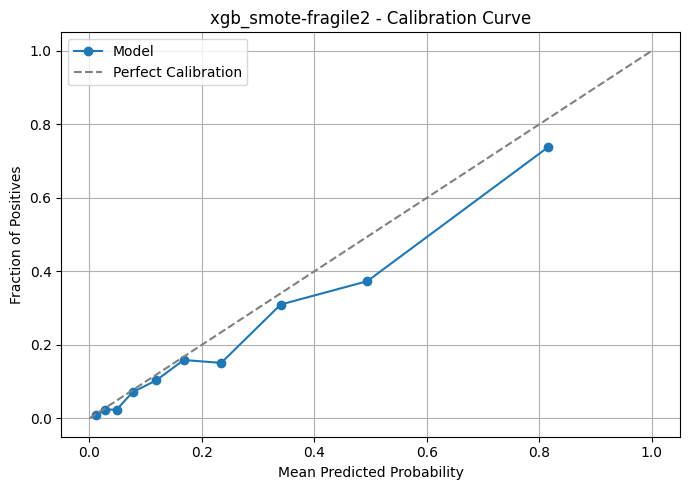

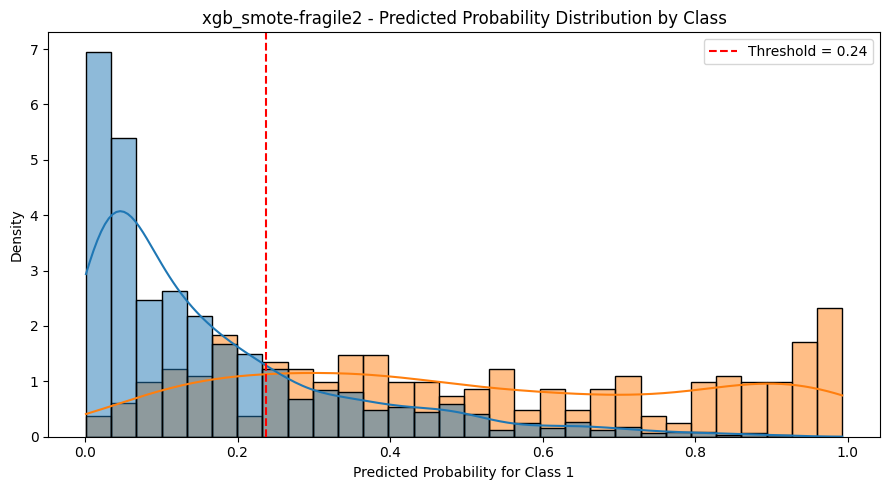


📊 Classification Report (Threshold = 0.24):
              precision    recall  f1-score   support

         0.0      0.934     0.759     0.838      1014
         1.0      0.442     0.781     0.564       247

    accuracy                          0.764      1261
   macro avg      0.688     0.770     0.701      1261
weighted avg      0.838     0.764     0.784      1261


📈 Train RMSE: 0.2688
📈 Test  RMSE: 0.3310

📉 Business Cost Evaluation for xgb_smote-fragile2:
🔹 Best Threshold (Cost-Optimized): 0.238
🔹 Expected Loss: 0.365  [FN cost = 4, FP cost = 1]

📊 xgb_smote-fragile2: Train RMSE = 0.2688, Valid RMSE = 0.3310
✅ Finished: xgb_smote-fragile2



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [143]:
fragile_feature_list2 = [
    col for col in non_llm_features
    if col not in ['election_certainty', 'election_keyword_count']
]


# ✅ XGBoost pipeline
pipe_xgb_fragile2 = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(verbosity=0, random_state=SEED))
])

lib.helper_fun.run_model_with_gridsearch('xgb_smote-fragile2', pipe_xgb_fragile2, xgb_param_grid, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.diagnostics, collector_non_llm,
    fragile_feature_list2, categorical_features
)

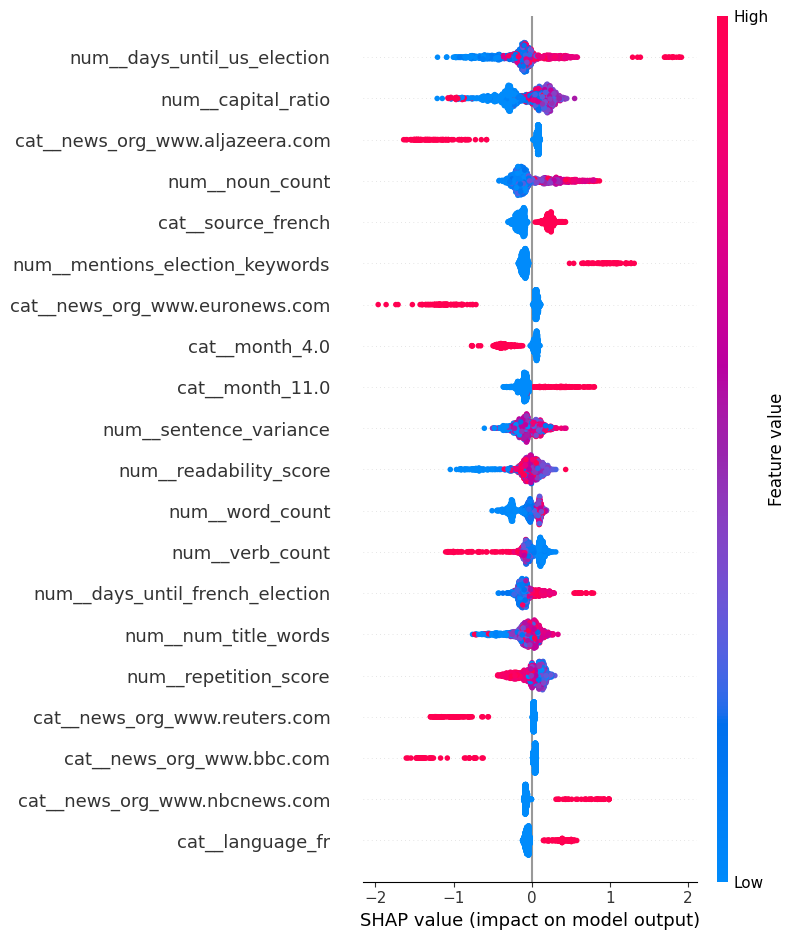

In [145]:
fragile_model = best_models['xgb_smote-fragile2']

final_estimatorf2 = fragile_model.named_steps['model']
encoded_feature_names = fragile_model.named_steps['preprocessor'].get_feature_names_out()


explainer = shap.TreeExplainer(final_estimatorf2)
X_valid_processed = fragile_model.named_steps['preprocessor'].transform(X_valid[fragile_feature_list])
shap_values = explainer.shap_values(X_valid_processed)

shap.summary_plot(shap_values, X_valid_processed, feature_names=encoded_feature_names)

| Model                          | Test RMSE | Expected Loss | F1 Score | Precision | Recall |
|-------------------------------|-----------|----------------|----------|-----------|--------|
| Original (All Features)       | ✅ Best    | ✅ Best         | 🔼 High   | 🔼 High    | 🔼 High |
| Fragility Test 1 (No EC)      | 🔻 Worse   | 🔻 Higher       | 🔻 Lower  | 🔻 Lower   | ➖ Stable |
| Fragility Test 2 (No EC + P%) | 🔻 Similar | 🔻 Slightly ↓   | ➖ Similar| ➖ Slight  | ➖ Stable |

## rmse tables again 

In [146]:
collector_non_llm.get_table()

,Train RMSE,Test RMSE,Expected Loss
Logit-Baseline,0.445,0.441,0.502
Logit-non_llm,0.343,0.337,0.284
xgb_not_calibrated_no_smote,0.214,0.275,0.259
xgb_smote_not_calibrated,0.232,0.273,0.238
xgb_calibrated_no_smote,0.237,0.276,0.259
xgb_calibrated_smote-non_llm,0.228,0.276,0.254
xgb_new_smote-non_llm,0.222,0.276,0.259
xgb_pca-non_llm,0.294,0.334,0.278
xgb_select-non_llm,0.270,0.301,0.268
xgb_smote-non_llm-betterGS,0.232,0.273,0.238


In [149]:
collector_non_llm_pub.get_table()

,Train RMSE,Test RMSE,Expected Loss
Logit-non_llm+pub,0.344,0.337,0.282
xgb_smote-non_llm+pub,0.231,0.274,0.249
xgb_new_smote-non_llm+pub,0.219,0.274,0.256
xgb_pca-non_llm+pub,0.237,0.315,0.270
xgb_select-non_llm+pub,0.251,0.290,0.278
rf-non_llm+pub,0.210,0.293,0.259


In [150]:
collector_llm.get_table()


,Train RMSE,Test RMSE,Expected Loss
Logit-llm,0.332,0.329,0.262
xgb_smote-llm,0.221,0.265,0.238
xgb_new_smote-llm,0.204,0.261,0.232
xgb_pca-llm,0.226,0.316,0.287
xgb_select-llm,0.250,0.279,0.256
xgb_smote-llm-betterGS,0.221,0.265,0.238
rf-llm,0.147,0.280,0.234


## question - why was the days until feature not a good predictor? 

In [518]:
#fn_df[['days_until_us_election', 'days_until_german_election', 'days_until_french_election']].describe()
data.groupby(['is_relevant', 'source'])[
    ['days_until_us_election', 'days_until_german_election', 'days_until_french_election']
].describe().round(3).T

is_relevant                            0.0                          1.0  \
source                              french    german        us   french   
days_until_us_election     count  1620.000  1776.000  1671.000  431.000   
                           mean   -142.892  -143.543    19.934  -54.654   
                           std      55.569    26.100    23.512  126.774   
                           min    -195.000  -191.000  -167.000 -195.000   
                           25%    -189.000  -160.000     0.500 -154.000   
                           50%    -157.500  -154.000    20.000 -112.000   
                           75%    -122.000  -139.000    40.000  119.000   
                           max     183.000   -48.000    61.000  189.000   
days_until_german_election count  1620.000  1776.000  1671.000  431.000   
                           mean    -32.892   -33.543   129.934   55.346   
                           std      55.569    26.100    23.512  126.774   
                           min     -85.000   -81.000   -57.000  -85.000   
                           25%     -79.000   -50.000   110.500  -44.000   
                           50%     -47.500   -44.000   130.000   -2.000   
                           75%     -12.000   -29.000   150.000  229.000   
                           max     293.000    62.000   171.000  299.000   
days_until_french_election count  1620.000  1776.000  1671.000  431.000   
                           mean   -263.892  -264.543  -101.066 -175.654   
                           std      55.569    26.100    23.512  126.774   
                           min    -316.000  -312.000  -288.000 -316.000   
                           25%    -310.000  -281.000  -120.500 -275.000   
                           50%    -278.500  -275.000  -101.000 -233.000   
                           75%    -243.000  -260.000   -81.000   -2.000   
                           max      62.000  -169.000   -60.000   68.000   

is_relevant                                         
source                             german       us  
days_until_us_election     count  209.000  596.000  
                           mean  -139.024   11.671  
                           std     41.172   20.956  
                           min   -167.000  -18.000  
                           25%   -159.000   -2.000  
                           50%   -155.000    1.000  
                           75%   -137.000   24.000  
                           max    299.000   61.000  
days_until_german_election count  209.000  596.000  
                           mean   -29.024  121.671  
                           std     41.172   20.956  
                           min    -57.000   92.000  
                           25%    -49.000  108.000  
                           50%    -45.000  111.000  
                           75%    -27.000  134.000  
                           max    409.000  171.000  
days_until_french_election count  209.000  596.000  
                           mean  -260.024 -109.329  
                           std     41.172   20.956  
                           min   -288.000 -139.000  
                           25%   -280.000 -123.000  
                           50%   -276.000 -120.000  
                           75%   -258.000  -97.000  
                           max    178.000  -60.000

### 📉 Why Are Relevant French and German Articles Published *After* the Election?

During analysis, we noticed that even for **relevant articles**, the `days_until_french_election` and `days_until_german_election` values were often negative — meaning the articles were published **after** the respective election dates.

#### ❓ Is That a Problem?

No — in fact, it's expected.

#### 🧠 Why?

The label "relevant" includes not just pre-election campaign coverage, but also **post-election developments**, such as:

- Coalition negotiations
- Leadership appointments (e.g., "Kanzler in spe")
- Policy shifts and budget debates
- Reactions from youth political groups (e.g., Jusos)
- Voter turnout and protest analysis
- Public dissatisfaction or political fallout

These events are part of the **election aftermath**, and are highly relevant to understanding the political outcome.

#### 🌍 Why Is This More Common in French and German Sources?

- U.S. media has a larger volume of **pre-election coverage**.
- French and German sources in the dataset focus more heavily on **post-election analysis**.
- This reflects the media cycle: European politics often get **increased coverage after results are in**, especially with coalition-style governments.

#### ✅ Key Insight

A negative `days_until_*_election` does **not** imply irrelevance. It simply means the article was published after the election date — and many such articles are still **highly relevant** to understanding election outcomes and political shifts.

Your model is correctly learning this pattern, rather than naively assuming that only pre-election articles are relevant.

## investigating the misclassified articles

### fn and fp df 

In [151]:
y_pred = (valid_probs >=  0.29).astype(int)

In [152]:
import pandas as pd

fp_idx = (y_valid == 0) & (y_pred == 1)  # False Positives
fn_idx = (y_valid == 1) & (y_pred == 0)  # False Negatives

false_positives = X_valid[fp_idx]
false_negatives = X_valid[fn_idx]

# Optional: if you want to see probabilities too
false_positives_probs = valid_probs[fp_idx]
false_negatives_probs = valid_probs[fn_idx]

# Combine into one DataFrame for inspection
fp_df = pd.DataFrame(false_positives).copy()
fp_df['probability'] = false_positives_probs
fp_df['true_label'] = 0
fp_df['predicted_label'] = 1

fn_df = pd.DataFrame(false_negatives).copy()
fn_df['probability'] = false_negatives_probs
fn_df['true_label'] = 1
fn_df['predicted_label'] = 0

In [153]:
print(fp_df.shape)# Top false positives
fn_df.shape  # Top false negatives

(112, 66)


(48, 66)

In [522]:
#fn_df.loc[fn_df.index == 3942, 'description'].tolist()

pd.set_option('display.max_colwidth', None)
fn_df["description"].head(41)

6019    PARIS — France is barreling toward a perfect storm of political and financial crisis as 2024 comes to a close. Marine Le Pen’s far-right National Rally is threatening to pull the plug on the fragile coalition government led by Prime Minister Michel Barnier over the conservative grandee's plans to rein in the massive French deficit.
1459                                                                                                                                                                                     Health and Human Services Secretary Robert Kennedy Jr. is directing the CDC to change its recommendation on fluoride in drinking water. Here’s what to know.
8                                                                                                                                                           Kamala Harris’s abortion policies, explained. Kamala Harris has been a leading voice on reproductive rights, and wants Congress to pass a national law codifying

In [154]:
data.used_description_as_text.value_counts()
fn_df.language.value_counts(normalize=True)


language
en    0.583
de    0.333
fr    0.083
Name: proportion, dtype: float64

In [155]:
data.used_description_as_text.value_counts()
fn_df.used_description_as_text.value_counts(normalize=True)
fn_df.P_news_org_article_share.value_counts()
fn_df.used_description_as_text.value_counts(normalize=True)

used_description_as_text
0    0.667
1    0.333
Name: proportion, dtype: float64

# error analysis by subgroup 

#### only eng lang 


In [156]:
X_valid.language.value_counts()

language
en    884
de    224
fr    153
Name: count, dtype: int64

In [158]:
# 1️⃣ Filter the validation set to only include English-language articles
english_mask = X_valid['language'] == 'en'
X_valid_en = X_valid[english_mask]
y_valid_en = y_valid[english_mask]

# 2️⃣ Get predictions for this English-only subset
valid_probs_en = xgb_model.predict_proba(X_valid_en[non_llm_features_with_publisher])[:, 1]
threshold = 0.29  # or use your preferred threshold
y_pred_en = (valid_probs_en >= threshold).astype(int)

# 3️⃣ Identify false positives and false negatives
fp_mask = (y_valid_en == 0) & (y_pred_en == 1)
fn_mask = (y_valid_en == 1) & (y_pred_en == 0)

fp_df_en = X_valid_en[fp_mask].copy()
fn_df_en = X_valid_en[fn_mask].copy()

# 4️⃣ Optionally, include the true label and predicted probability for inspection
fp_df_en['true_label'] = y_valid_en[fp_mask]
fp_df_en['pred_prob'] = valid_probs_en[fp_mask]

fn_df_en['true_label'] = y_valid_en[fn_mask]
fn_df_en['pred_prob'] = valid_probs_en[fn_mask]

# 5️⃣ Display results (you can also export or visually inspect a few)
print("🔹 English Articles:")
print(y_valid_en.shape[0])
print("🔹 False Positives in English Articles:")
print(fp_df_en.shape[0])

print("🔹 False Negatives in English Articles:")
print(fn_df_en.shape[0])

🔹 English Articles:
884
🔹 False Positives in English Articles:
49
🔹 False Negatives in English Articles:
28


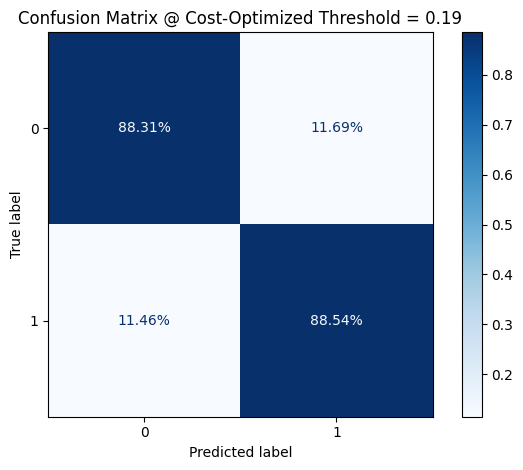

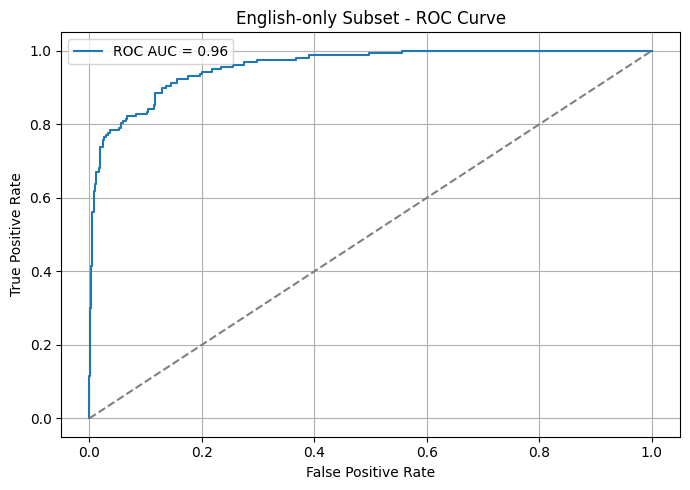

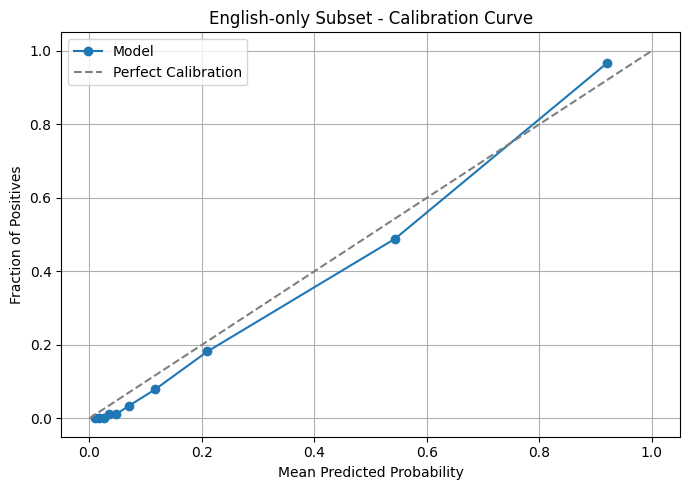

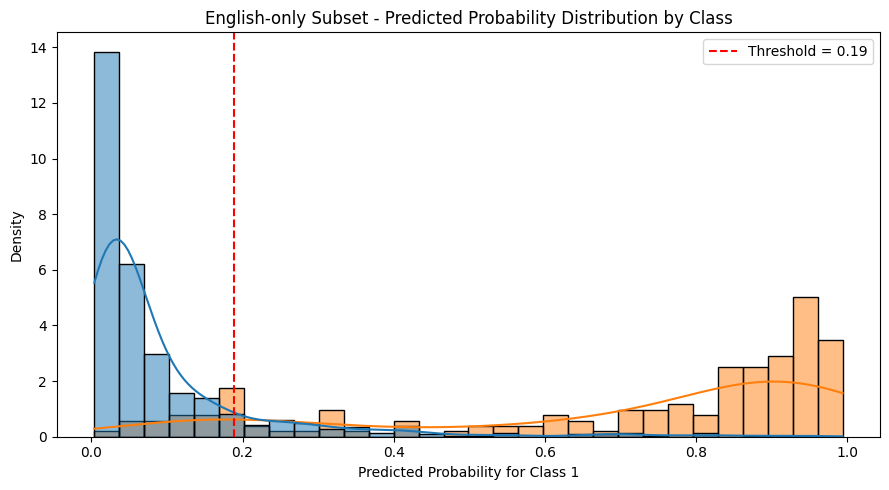


📊 Classification Report (Threshold = 0.19):
              precision    recall  f1-score   support

         0.0      0.973     0.883     0.926       727
         1.0      0.621     0.885     0.730       157

    accuracy                          0.883       884
   macro avg      0.797     0.884     0.828       884
weighted avg      0.910     0.883     0.891       884


📈 Train RMSE: 0.2325
📈 Test  RMSE: 0.2325


{'Model': 'English-only Subset',
 'Threshold': 0.188,
 'Train RMSE': 0.233,
 'Test RMSE': 0.233,
 'AUC': 0.957}

In [159]:
# 2️⃣ Get prediction probabilities
valid_probs_en = xgb_model.predict_proba(X_valid_en[non_llm_features_with_publisher])[:, 1]

# 3️⃣ Compute best threshold
threshold_en, expected_loss_en = lib.helper_fun.compute_expected_loss(y_valid_en, valid_probs_en)

# 4️⃣ Predict using best threshold
y_pred_en = (valid_probs_en >= threshold_en).astype(int)

# 5️⃣ Show confusion matrix using your custom function
lib.helper_fun.diagnostics(
    y_train=y_valid_en,  # for simplicity, using same as valid
    y_train_probs=valid_probs_en,
    y_valid=y_valid_en,
    y_valid_probs=valid_probs_en,
    model_name="English-only Subset"
)

In [160]:
# 1️⃣ Get the final predictions at the best threshold
y_pred_en = (valid_probs_en >= threshold_en).astype(int)

# 2️⃣ Compute the confusion matrix
tn, fp, fn, tp = confusion_matrix(y_valid_en, y_pred_en).ravel()

# 3️⃣ Set costs for false positives (FP) and false negatives (FN)
fp_cost = 1
fn_cost = 4

# 4️⃣ Compute the total number of samples
total_samples = tn + fp + fn + tp

# 5️⃣ Compute the expected loss
expected_loss_final = (fp * fp_cost + fn * fn_cost) / total_samples

print(f"Expected Loss on English-only subset: {expected_loss_final:.4f}")

Expected Loss on English-only subset: 0.1776


#### full text only

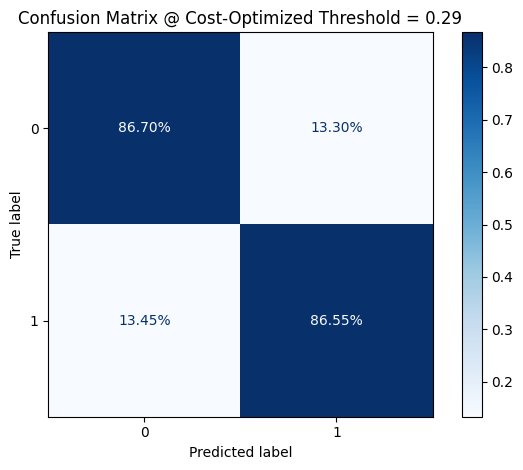

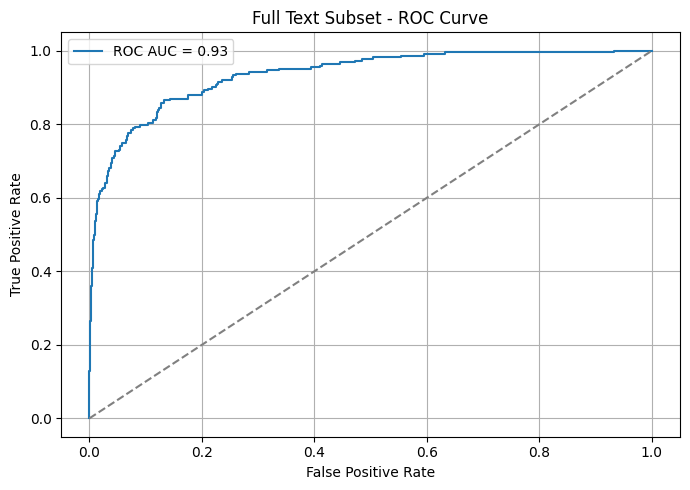

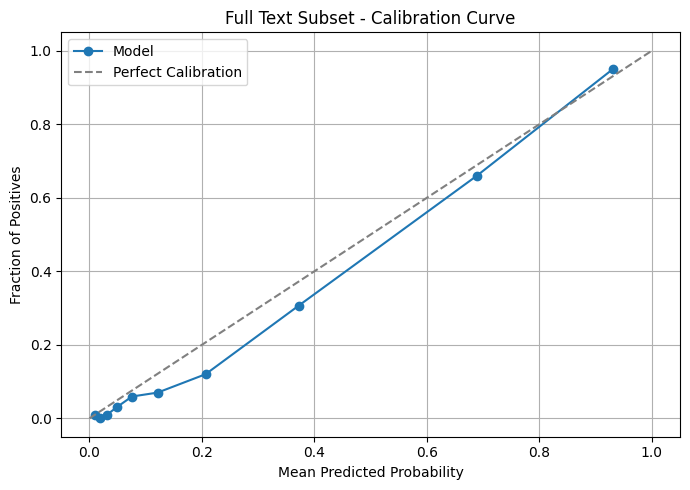

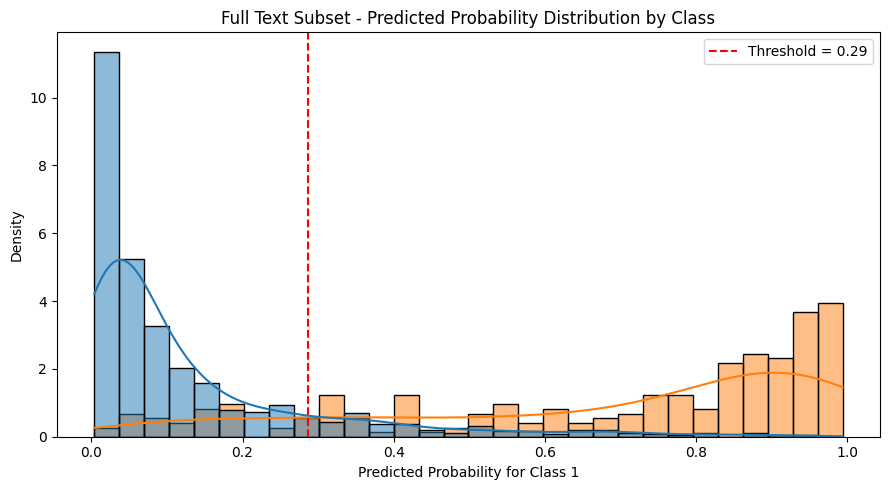


📊 Classification Report (Threshold = 0.29):
              precision    recall  f1-score   support

         0.0      0.958     0.867     0.910       782
         1.0      0.650     0.865     0.742       223

    accuracy                          0.867      1005
   macro avg      0.804     0.866     0.826      1005
weighted avg      0.889     0.867     0.873      1005


📈 Train RMSE: 0.2753
📈 Test  RMSE: 0.2753


{'Model': 'Full Text Subset',
 'Threshold': 0.287,
 'Train RMSE': 0.275,
 'Test RMSE': 0.275,
 'AUC': 0.935}

In [161]:
# 1️⃣ Filter for articles that use full text (i.e., not just description)
text_mask = X_valid['used_description_as_text'] == 0
X_valid_text = X_valid[text_mask]
y_valid_text = y_valid[text_mask]

# 2️⃣ Get prediction probabilities for these articles
valid_probs_text = xgb_model.predict_proba(X_valid_text[non_llm_features_with_publisher])[:, 1]

# 3️⃣ Compute best threshold using your expected loss function
threshold_text, expected_loss_text = lib.helper_fun.compute_expected_loss(y_valid_text, valid_probs_text)

# 4️⃣ Show confusion matrix using your custom matrix function
lib.helper_fun.diagnostics(
    y_train=y_valid_text,  # for simplicity, using same as valid
    y_train_probs=valid_probs_text,
    y_valid=y_valid_text,
    y_valid_probs=valid_probs_text,
    model_name="Full Text Subset"
)

In [162]:
# 1️⃣ Predict with the best threshold
y_pred_text = (valid_probs_text >= threshold_text).astype(int)

# 2️⃣ Compute confusion matrix
tn, fp, fn, tp = confusion_matrix(y_valid_text, y_pred_text).ravel()

# 3️⃣ Set costs for false positives (FP) and false negatives (FN)
fp_cost = 1
fn_cost = 4

# 4️⃣ Compute total number of samples
total_samples = tn + fp + fn + tp

# 5️⃣ Calculate expected loss
expected_loss_final_text = (fp * fp_cost + fn * fn_cost) / total_samples

print(f"Expected Loss on Full Text subset: {expected_loss_final_text:.4f}")

Expected Loss on Full Text subset: 0.2229


Expected Loss on English + Full Text subset: 0.1364


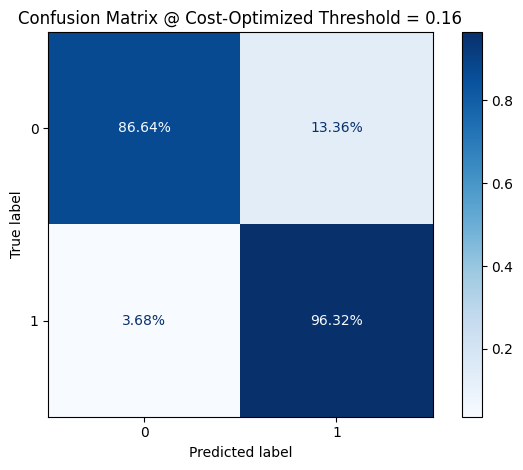

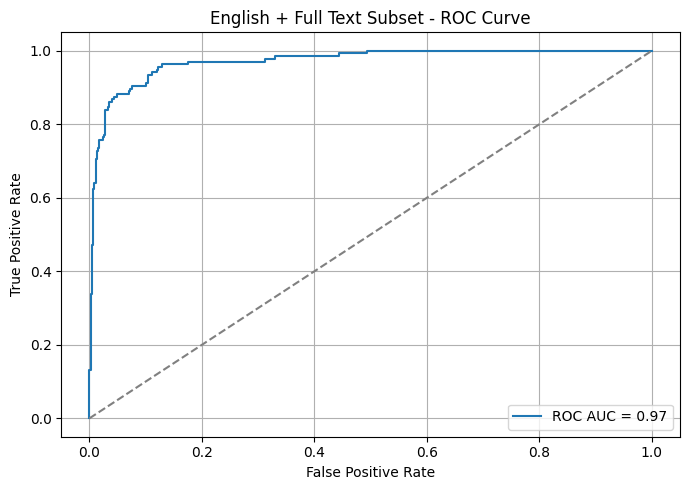

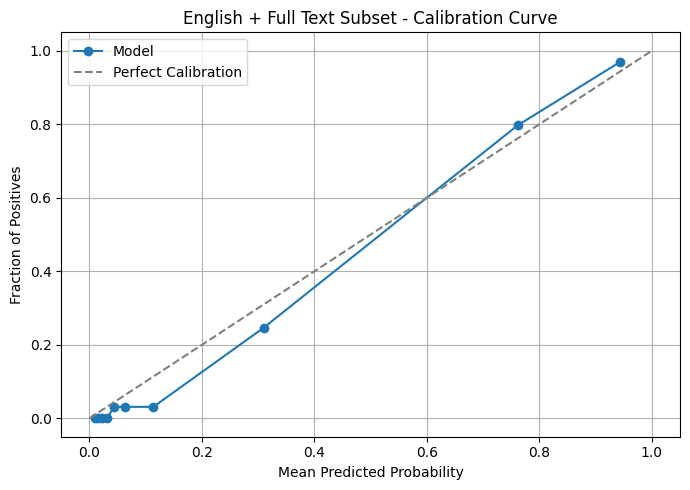

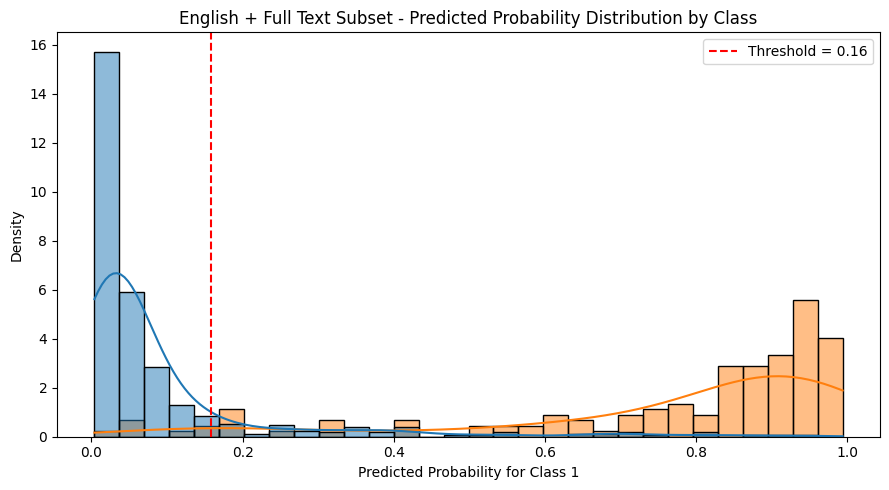


📊 Classification Report (Threshold = 0.16):
              precision    recall  f1-score   support

         0.0      0.989     0.866     0.924       509
         1.0      0.658     0.963     0.782       136

    accuracy                          0.887       645
   macro avg      0.824     0.915     0.853       645
weighted avg      0.919     0.887     0.894       645


📈 Train RMSE: 0.2207
📈 Test  RMSE: 0.2207


{'Model': 'English + Full Text Subset',
 'Threshold': 0.158,
 'Train RMSE': 0.221,
 'Test RMSE': 0.221,
 'AUC': 0.971}

In [163]:
# 1️⃣ Combined Filter: English and Full Text
combined_mask = (X_valid['language'] == 'en') & (X_valid['used_description_as_text'] == 0)
X_valid_en_text = X_valid[combined_mask]
y_valid_en_text = y_valid[combined_mask]

# 2️⃣ Get prediction probabilities for these articles
valid_probs_en_text = xgb_model.predict_proba(X_valid_en_text[non_llm_features_with_publisher])[:, 1]

# 3️⃣ Compute best threshold using your expected loss function
threshold_en_text, expected_loss_en_text = lib.helper_fun.compute_expected_loss(y_valid_en_text, valid_probs_en_text)

# 4️⃣ Predict with best threshold
y_pred_en_text = (valid_probs_en_text >= threshold_en_text).astype(int)

# 5️⃣ Calculate expected loss manually
tn, fp, fn, tp = confusion_matrix(y_valid_en_text, y_pred_en_text).ravel()
fp_cost = 1
fn_cost = 4
total_samples = tn + fp + fn + tp
expected_loss_final_en_text = (fp * fp_cost + fn * fn_cost) / total_samples

print(f"Expected Loss on English + Full Text subset: {expected_loss_final_en_text:.4f}")

# 6️⃣ Show diagnostics (Confusion matrix, ROC, Calibration)
lib.helper_fun.diagnostics(
    y_train=y_valid_en_text,  # for simplicity, same as valid
    y_train_probs=valid_probs_en_text,
    y_valid=y_valid_en_text,
    y_valid_probs=valid_probs_en_text,
    model_name="English + Full Text Subset"
)

# threshold optimization by subgroup

In [164]:
# Make a combined DataFrame for subgroup filtering
X_valid_with_y = X_valid.copy()
X_valid_with_y["y_true"] = y_valid
X_valid_with_y["y_prob"] = valid_probs  # assuming this is from your best model


subgroups = {
    "language_en": X_valid_with_y["language"] == "en",
    "language_fr": X_valid_with_y["language"] == "fr",
    "language_de": X_valid_with_y["language"] == "de",
    "text_full": X_valid_with_y["used_description_as_text"] == 0,
    "text_short": X_valid_with_y["used_description_as_text"] == 1
}

threshold_results = {}

for name, mask in subgroups.items():
    subset = X_valid_with_y[mask]
    
    if len(subset) > 0:
        threshold, loss = lib.helper_fun.compute_expected_loss(
            y_true=subset["y_true"],
            y_probs=subset["y_prob"]
        )
        threshold_results[name] = {
            "Optimal Threshold": round(threshold, 3),
            "Expected Loss": round(loss, 4),
            "Sample Size": len(subset)
        }

threshold_df = pd.DataFrame(threshold_results).T
threshold_df

,Optimal Threshold,Expected Loss,Sample Size
language_en,0.188,0.178,884.0
language_fr,0.287,0.438,153.0
language_de,0.267,0.312,224.0
text_full,0.287,0.223,1005.0
text_short,0.188,0.270,256.0


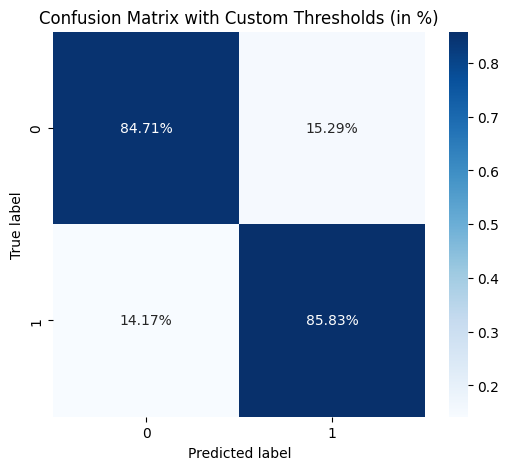


📊 Classification Report:
               precision    recall  f1-score   support

         0.0       0.96      0.85      0.90      1014
         1.0       0.58      0.86      0.69       247

    accuracy                           0.85      1261
   macro avg       0.77      0.85      0.80      1261
weighted avg       0.89      0.85      0.86      1261



In [167]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Map each row to its subgroup
def get_subgroup(row):
    if row['language'] == 'en':
        return 'language_en'
    elif row['language'] == 'fr':
        return 'language_fr'
    elif row['language'] == 'de':
        return 'language_de'
    elif row['used_description_as_text']:
        return 'text_short'
    else:
        return 'text_full'

# Apply subgroup logic
X_valid_augmented = X_valid.copy()
X_valid_augmented['probs'] = valid_probs
X_valid_augmented['true_label'] = y_valid.values
X_valid_augmented['subgroup'] = X_valid_augmented.apply(get_subgroup, axis=1)

# Step 2: Map custom thresholds
threshold_map = {
    'language_en': 0.188,
    'language_fr': 0.287,
    'language_de': 0.267,
    'text_full': 0.287,
    'text_short': 0.188
}
X_valid_augmented['threshold'] = X_valid_augmented['subgroup'].map(threshold_map)

# Step 3: Apply row-wise threshold
X_valid_augmented['y_pred_custom'] = (X_valid_augmented['probs'] >= X_valid_augmented['threshold']).astype(int)

# Step 4: Confusion matrix and classification report
y_true_custom = X_valid_augmented['true_label']
y_pred_custom = X_valid_augmented['y_pred_custom']
cm = confusion_matrix(y_true_custom, y_pred_custom)
cm_percent = cm / cm.sum(axis=1, keepdims=True)

# 🔁 Plot confusion matrix with percentages
plt.figure(figsize=(6, 5))
sns.heatmap(cm_percent, annot=True, fmt=".2%", cmap="Blues", xticklabels=[0, 1], yticklabels=[0, 1])
plt.title("Confusion Matrix with Custom Thresholds (in %)")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

# 📊 Print classification report
print("\n📊 Classification Report:\n", classification_report(y_true_custom, y_pred_custom))

In [168]:
# Confusion matrix (already calculated)
TN, FP, FN, TP = cm.ravel()

# Costs
fp_cost = 1
fn_cost = 4

# Total number of samples
total_samples = cm.sum()

# Expected loss calculation
expected_loss = (FP * fp_cost + FN * fn_cost) / total_samples

print(f"Expected Loss: {expected_loss:.4f}")

Expected Loss: 0.2339
